
# Shanghai Current Housing Market

This section covers all data visualizations found within 2.2.1 Current Housing Market

We used these datasets below to produce relevant visualizations

- `lianjia_buy_clean_20260606.csv`
- `lianjia_rent_clean_20260606.csv`
- `shanghai_housing_prices.csv`
- `shanghai_housing_prices_annual.csv`
- `shanghai_income_final.csv`


In [1]:

from pathlib import Path

project_root = Path.cwd().parent

data_dir = project_root / 'data'

required_files = [
    "lianjia_buy_clean_20260606.csv",
    "lianjia_rent_clean_20260606.csv",
    "shanghai_housing_prices.csv",
    "shanghai_housing_prices_annual.csv",
    "shanghai_income_final.csv",
]

missing = [name for name in required_files if not (data_dir / name).exists()]

if missing:
    print("Missing files in data folder:")
    for name in missing:
        print(f"  - {name}")
    print(f"\nPlease place the files in: Shanghai_Housing/data/")
else:
    print(f"All required files found")


All required files found


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
from scipy import stats
import statsmodels.formula.api as smf

buy = pd.read_csv(data_dir / "lianjia_buy_clean_20260606.csv")
rent = pd.read_csv(data_dir / "lianjia_rent_clean_20260606.csv")
monthly = pd.read_csv(data_dir / "shanghai_housing_prices.csv")
annual = pd.read_csv(data_dir / "shanghai_housing_prices_annual.csv")
income = pd.read_csv(data_dir / "shanghai_income_final.csv")

YELLOW = "#FD9D24"
TEAL = "#2A9D8F"
NAVY = "#264653"
ORANGE = "#F4A261"
CORAL = "#E76F51"
GREY = "#777777"
LIGHT_GREY = "#D9DEDF"
BLACK = 'black'

PALETTE = [TEAL, CORAL, ORANGE, NAVY, YELLOW]
PROJECT_CMAP = LinearSegmentedColormap.from_list(
    "project_palette",
    [NAVY, TEAL, YELLOW, ORANGE, CORAL],
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": LIGHT_GREY,
    "axes.labelcolor": NAVY,
    "axes.titlecolor": NAVY,
    "axes.prop_cycle": cycler(color=PALETTE),
    "xtick.color": GREY,
    "ytick.color": GREY,
    "text.color": NAVY,
    "legend.frameon": False,
    "font.size": 10,
    "font.family": "Arial",
})

def set_chart_title(title, question):
    ax = plt.gca()
    fig = plt.gcf()
    fig.subplots_adjust(top=0.88)
    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold",
        color=BLACK,
        pad=15,
        loc='center',
    )
    ax.text(
        0.5,
        1.02,
        question,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=10,
        color=GREY,
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def ranked_colors(length, low_count=3, high_count=2):
    colors = [TEAL] * length

    for index in range(min(low_count, length)):
        colors[index] = ORANGE

    for index in range(max(0, length - high_count), length):
        colors[index] = CORAL

    return colors

def palette_colors(length):
    return [PALETTE[index % len(PALETTE)] for index in range(length)]

def styled_boxplot(*args, **kwargs):
    if "labels" in kwargs and "tick_labels" not in kwargs:
        kwargs["tick_labels"] = kwargs.pop("labels")

    kwargs["patch_artist"] = True
    boxplot = plt.boxplot(*args, **kwargs)

    for index, box in enumerate(boxplot["boxes"]):
        box.set_facecolor(PALETTE[index % len(PALETTE)])
        box.set_alpha(0.75)
        box.set_edgecolor(NAVY)

    for median in boxplot["medians"]:
        median.set_color(NAVY)
        median.set_linewidth(1.8)

    for whisker in boxplot["whiskers"]:
        whisker.set_color(GREY)

    for cap in boxplot["caps"]:
        cap.set_color(GREY)

    for flier in boxplot["fliers"]:
        flier.set_markerfacecolor(CORAL)
        flier.set_markeredgecolor(CORAL)
        flier.set_alpha(0.45)

    return boxplot

print("Sale listings:", len(buy))
print("Rental listings:", len(rent))
print("Monthly price rows:", len(monthly))
print("Annual price rows:", len(annual))
print("Income rows:", len(income))

Sale listings: 2084
Rental listings: 1852
Monthly price rows: 2020
Annual price rows: 175
Income rows: 10



## 1. Data quality and preparation

Medians are used for current-market comparisons because prices and rents are right-skewed. Two 1 sqm rental observations are removed only from rent-per-sqm analysis.


In [9]:

buy["district_std"] = buy["district_en"].astype(str).str.replace("'", "", regex=False).str.strip()
rent["district_std"] = rent["district"].astype(str).str.replace("'", "", regex=False).str.title().str.strip()
monthly["district_std"] = monthly["district"].astype(str).str.replace("'", "", regex=False).str.strip()
annual["district_std"] = annual["district"].astype(str).str.replace("'", "", regex=False).str.strip()
monthly["date"] = pd.to_datetime(monthly["date"])

quality_rows = []
for name, data in {
    "Sale listings": buy,
    "Rental listings": rent,
    "Monthly prices": monthly,
    "Annual prices": annual,
    "Income": income,
}.items():
    quality_rows.append({
        "dataset": name,
        "rows": len(data),
        "duplicate_rows": data.duplicated().sum(),
        "missing_values": data.isna().sum().sum(),
    })

quality_summary = pd.DataFrame(quality_rows)
display(quality_summary)

rent_valid = rent[
    (rent["area_sqm"] >= 10)
    & (rent["rent_per_sqm"] < 1000)
].copy()

rent_valid["near_metro"] = rent_valid["tags"].fillna("").str.contains("近地铁", regex=False)
rent_valid["bedrooms"] = pd.to_numeric(
    rent_valid["layout"].str.extract(r"(\d+)")[0],
    errors="coerce",
)

def format_layout(value):
    match = pd.Series([value]).astype(str).str.extract(
        r"(?P<bedrooms>\d+)室(?P<living_rooms>\d+)厅(?P<bathrooms>\d+)卫"
    ).iloc[0]

    if match.isna().any():
        return str(value)

    return (
        f"{int(match['bedrooms'])} bed / "
        f"{int(match['living_rooms'])} living / "
        f"{int(match['bathrooms'])} bath"
    )

rent_valid["layout_en"] = rent_valid["layout"].apply(format_layout)

buy_age = buy[
    buy["property_age"].notna()
    & (buy["property_age"] >= 0)
].copy()

buy_age["age_group"] = pd.cut(
    buy_age["property_age"],
    bins=[-0.1, 10, 20, 30, 40, 100],
    labels=["0–10", "11–20", "21–30", "31–40", "41+"],
)

buy_summary = (
    buy.groupby("district_std")
    .agg(
        buy_listings=("listing_url", "count"),
        median_buy_price_sqm=("unit_price_yuan_sqm", "median"),
        median_total_price=("total_price_yuan", "median"),
        median_buy_area=("area_sqm", "median"),
    )
    .reset_index()
)

rent_summary = (
    rent_valid.groupby("district_std")
    .agg(
        rent_listings=("listing_url", "count"),
        median_rent_sqm=("rent_per_sqm", "median"),
        median_monthly_rent=("monthly_rent_yuan", "median"),
        median_rent_area=("area_sqm", "median"),
    )
    .reset_index()
)

market = buy_summary.merge(rent_summary, on="district_std")
market["price_to_rent_years"] = (
    market["median_buy_price_sqm"]
    / (market["median_rent_sqm"] * 12)
)
market["gross_rental_yield_pct"] = (
    market["median_rent_sqm"] * 12
    / market["median_buy_price_sqm"]
    * 100
)

display(market.round(2))


,dataset,rows,duplicate_rows,missing_values
0,Sale listings,2084,0,368
1,Rental listings,1852,0,128
2,Monthly prices,2020,0,0
3,Annual prices,175,0,0
4,Income,10,0,0


,district_std,buy_listings,median_buy_price_sqm,median_total_price,median_buy_area,rent_listings,median_rent_sqm,median_monthly_rent,median_rent_area,price_to_rent_years,gross_rental_yield_pct
0,Baoshan,121,35379.0,2850000.0,81.27,113,63.70,4200.0,75.54,46.28,2.16
1,Changning,118,65429.0,5230000.0,83.96,108,111.05,5787.5,51.25,49.10,2.04
2,Chongming,149,15143.0,1250000.0,87.22,150,21.80,1800.0,89.74,57.89,1.73
3,Fengxian,149,17227.0,1550000.0,88.87,119,30.00,2500.0,88.52,47.85,2.09
4,Hongkou,139,60896.0,4300000.0,75.05,120,97.55,5000.0,56.48,52.02,1.92
5,Huangpu,148,102145.0,11600000.0,113.68,122,133.00,7800.0,63.29,64.00,1.56
6,Jiading,116,31966.5,2590000.0,86.69,100,56.80,3790.0,71.82,46.90,2.13
7,Jingan,121,65353.0,4590000.0,72.21,115,106.50,6100.0,52.00,51.14,1.96
8,Jinshan,141,12265.0,1050000.0,89.66,144,26.00,2400.0,89.14,39.31,2.54
9,Minhang,115,45712.0,4290000.0,91.11,110,71.15,5000.0,77.16,53.54,1.87


## 2. Listing coverage

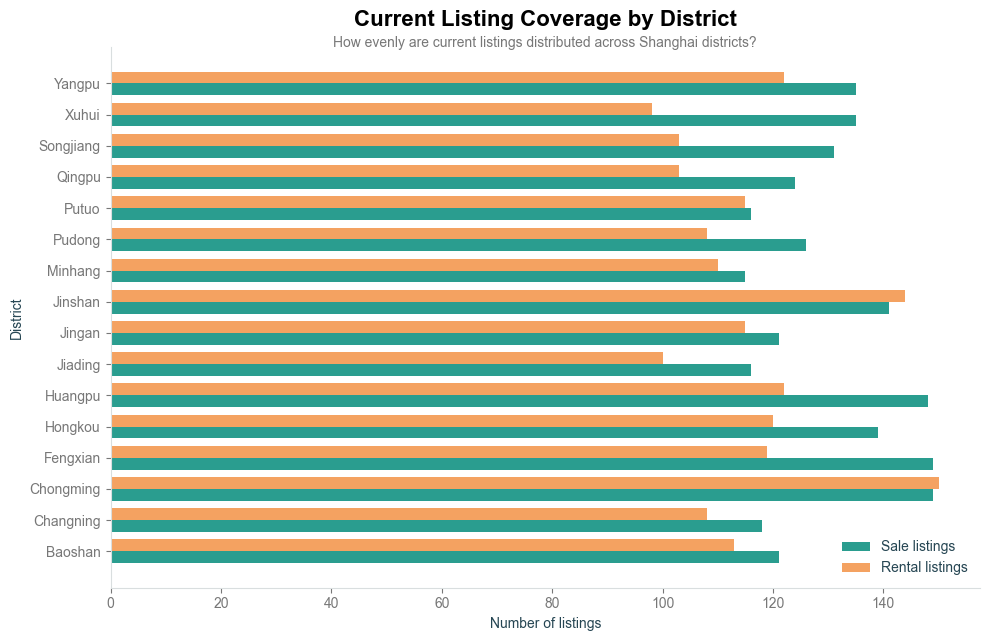

In [13]:

coverage = market.set_index("district_std")[["buy_listings", "rent_listings"]].sort_index()

positions = np.arange(len(coverage))
height = 0.38

plt.figure(figsize=(10, 7))
plt.barh(
    positions - height / 2,
    coverage["buy_listings"],
    height=height,
    label="Sale listings",
    color=TEAL,
)
plt.barh(
    positions + height / 2,
    coverage["rent_listings"],
    height=height,
    label="Rental listings",
    color=ORANGE,
)
plt.yticks(positions, coverage.index)
plt.xlabel("Number of listings")
plt.ylabel("District")
set_chart_title(
    "Current Listing Coverage by District",
    "How evenly are current listings distributed across Shanghai districts?",
)
plt.legend()
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()




The number of observations is fairly balanced across districts. Sale listings range from 115 to 149 per district, while rental listings range from 98 to 150. This reduces the risk that the district comparisons are driven mainly by unequal sample sizes, although Xuhui has the smallest rental sample.


## 3. Missing values

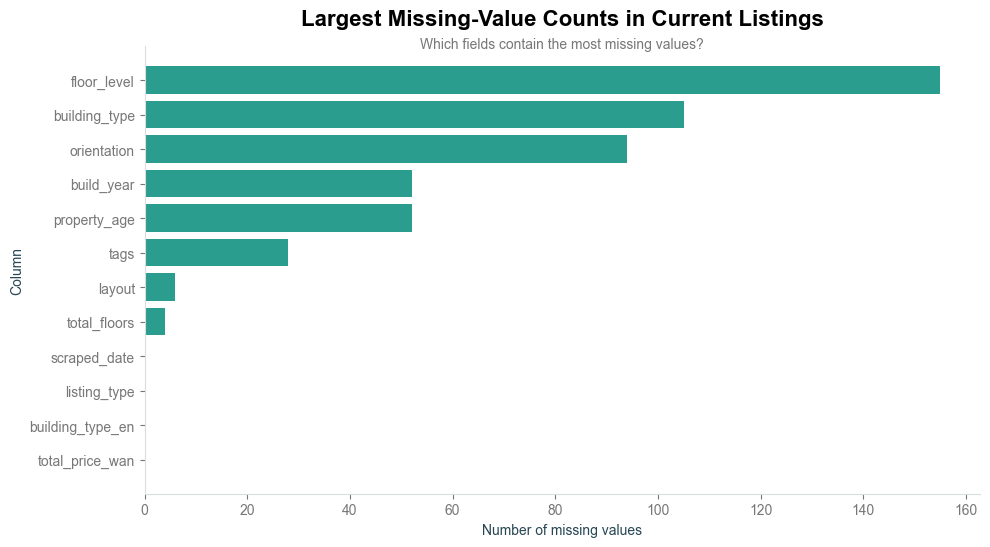

,Sale,Rent,total
floor_level,155.0,0.0,155.0
building_type,105.0,0.0,105.0
orientation,0.0,94.0,94.0
property_age,52.0,0.0,52.0
build_year,52.0,0.0,52.0
tags,0.0,28.0,28.0
layout,0.0,6.0,6.0
total_floors,4.0,0.0,4.0
district_en,0.0,0.0,0.0
district,0.0,0.0,0.0


In [16]:

missing_data = pd.concat(
    [
        buy.drop(columns=["district_std"]).isna().sum().rename("Sale"),
        rent.drop(columns=["district_std"]).isna().sum().rename("Rent"),
    ],
    axis=1,
).fillna(0)

missing_data["total"] = missing_data.sum(axis=1)
missing_top = missing_data.sort_values("total").tail(12)

plt.figure(figsize=(10, 6))
plt.barh(missing_top.index, missing_top["total"], color=TEAL)
plt.xlabel("Number of missing values")
plt.ylabel("Column")
set_chart_title(
    "Largest Missing-Value Counts in Current Listings",
    "Which fields contain the most missing values?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(missing_data.sort_values("total", ascending=False).head(15))


## 4. Purchase-price distribution

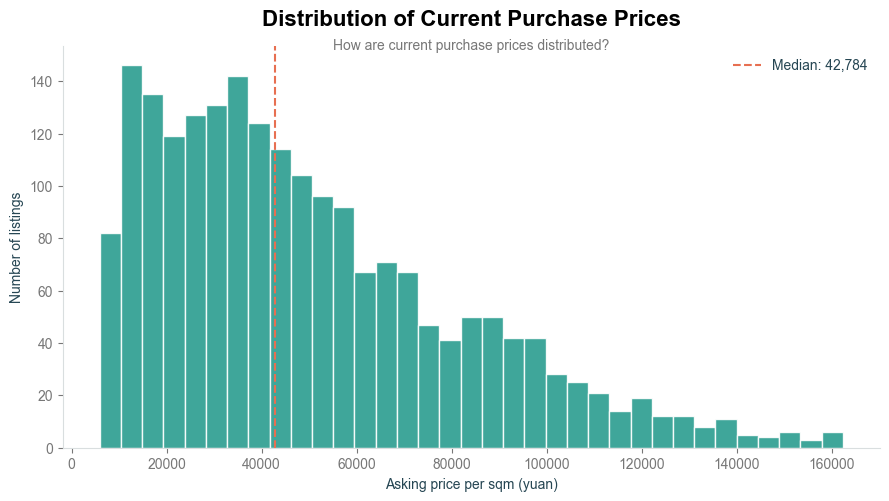

count      2084.000000
mean      51325.817658
std       34840.453794
min        5925.000000
10%       14151.400000
25%       25126.000000
50%       42784.000000
75%       69248.250000
90%       98561.900000
95%      118234.550000
99%      162713.440000
max      256497.000000
Name: unit_price_yuan_sqm, dtype: float64

In [17]:

median_price = buy["unit_price_yuan_sqm"].median()
cap = buy["unit_price_yuan_sqm"].quantile(0.99)

plt.figure(figsize=(9, 5.5))
plt.hist(
    buy.loc[buy["unit_price_yuan_sqm"] <= cap, "unit_price_yuan_sqm"],
    bins=35,
    color=TEAL,
    edgecolor="white",
    alpha=0.9,
)
plt.axvline(median_price, color=CORAL, linestyle="--", label=f"Median: {median_price:,.0f}")
plt.xlabel("Asking price per sqm (yuan)")
plt.ylabel("Number of listings")
set_chart_title(
    "Distribution of Current Purchase Prices",
    "How are current purchase prices distributed?",
)
plt.legend()
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(
    buy["unit_price_yuan_sqm"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)



Purchase prices are strongly right-skewed. The median is 42,784 yuan per sqm, while the mean is higher at 51,326 yuan because a relatively small group of premium listings pulls the average upward. This supports the use of medians for district comparisons.


## 5. Rental-price distribution

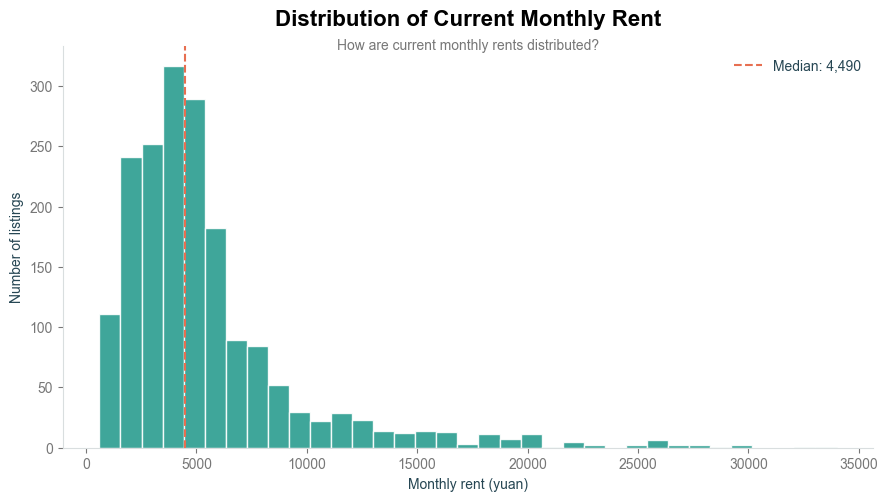

count      1850.000000
mean       5895.330811
std        6373.584294
min         600.000000
10%        1890.000000
25%        3000.000000
50%        4490.500000
75%        6300.000000
90%       11000.000000
95%       15365.000000
99%       34510.000000
max      128000.000000
Name: monthly_rent_yuan, dtype: float64

In [18]:

median_rent = rent_valid["monthly_rent_yuan"].median()
cap = rent_valid["monthly_rent_yuan"].quantile(0.99)

plt.figure(figsize=(9, 5.5))
plt.hist(
    rent_valid.loc[rent_valid["monthly_rent_yuan"] <= cap, "monthly_rent_yuan"],
    bins=35,
    color=TEAL,
    edgecolor="white",
    alpha=0.9,
)
plt.axvline(median_rent, color=CORAL, linestyle="--", label=f"Median: {median_rent:,.0f}")
plt.xlabel("Monthly rent (yuan)")
plt.ylabel("Number of listings")
set_chart_title(
    "Distribution of Current Monthly Rent",
    "How are current monthly rents distributed?",
)
plt.legend()
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(
    rent_valid["monthly_rent_yuan"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)



Monthly rent is also right-skewed. The median rent is about 4,491 yuan, compared with a mean of 5,895 yuan, and the upper tail contains several very expensive listings. A typical rental property is therefore better represented by the median than by the mean.


## 6. Purchase price by district

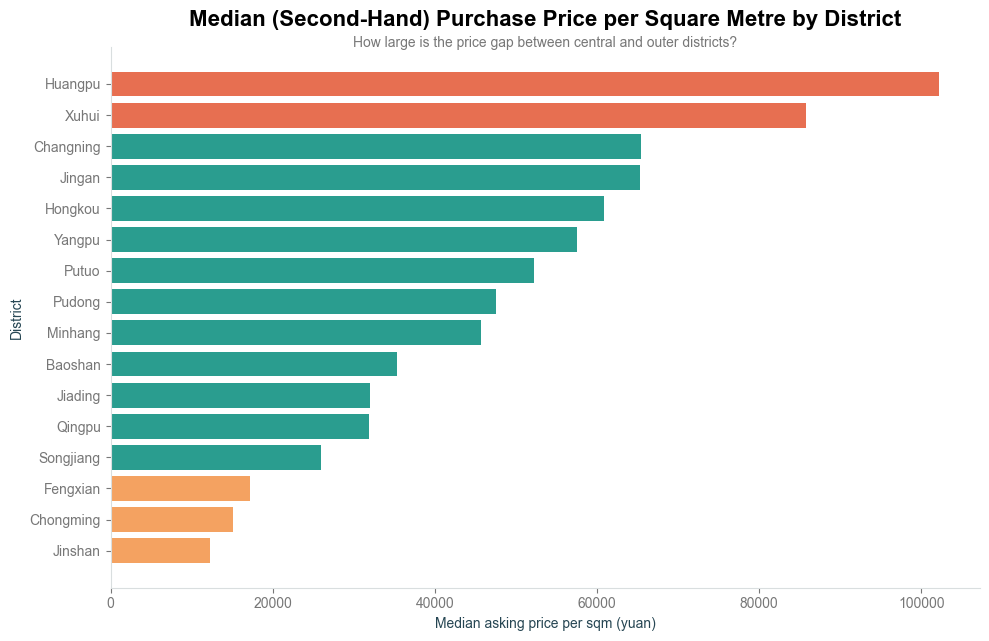

,district_std,median_buy_price_sqm,median_total_price
5,Huangpu,102145.0,11600000.0
14,Xuhui,85738.0,7090000.0
1,Changning,65429.0,5230000.0
7,Jingan,65353.0,4590000.0
4,Hongkou,60896.0,4300000.0
15,Yangpu,57513.0,4950000.0
11,Putuo,52251.0,4725000.0
10,Pudong,47582.0,3725000.0
9,Minhang,45712.0,4290000.0
0,Baoshan,35379.0,2850000.0


In [10]:

data = market.sort_values("median_buy_price_sqm")

plt.figure(figsize=(10, 7))
plt.barh(data["district_std"], data["median_buy_price_sqm"], color=ranked_colors(len(data)))
plt.xlabel("Median asking price per sqm (yuan)")
plt.ylabel("District")
set_chart_title(
    "Median (Second-Hand) Purchase Price per Square Metre by District",
    "How large is the price gap between central and outer districts?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(
    market.sort_values("median_buy_price_sqm", ascending=False)[
        ["district_std", "median_buy_price_sqm", "median_total_price"]
    ].round(0)
)



The purchase market shows a clear centre–periphery divide. Huangpu has the highest median unit price at 102,145 yuan per sqm, followed by Xuhui at 85,738 yuan, while Jinshan records only 12,265 yuan. The Huangpu median is more than eight times the Jinshan median, showing how strongly district choice affects the purchase budget.


## 7. Total asking price by district

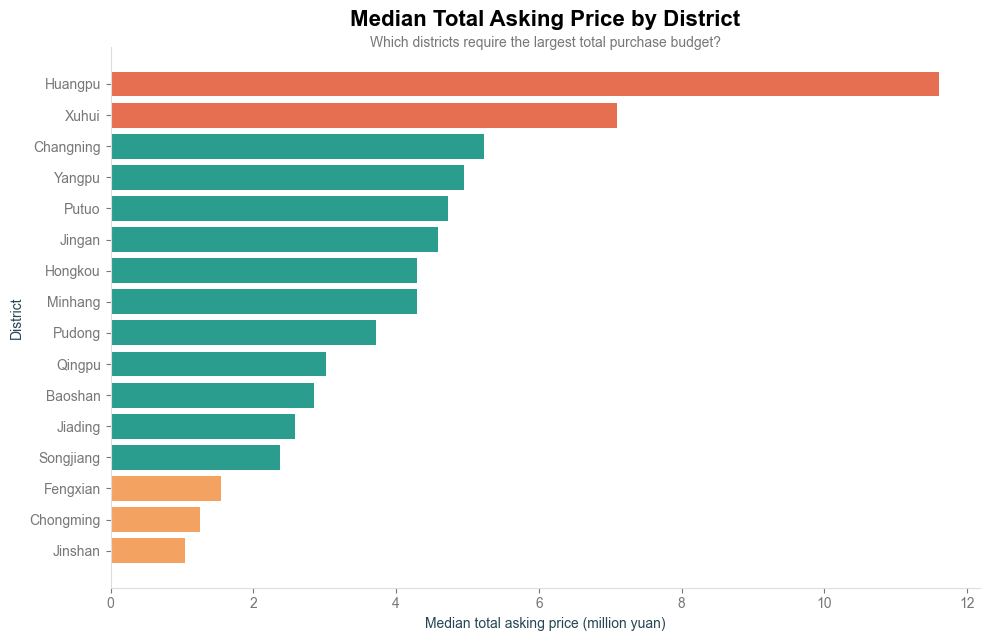

In [20]:

data = market.sort_values("median_total_price")

plt.figure(figsize=(10, 7))
plt.barh(data["district_std"], data["median_total_price"] / 1_000_000, color=ranked_colors(len(data)))
plt.xlabel("Median total asking price (million yuan)")
plt.ylabel("District")
set_chart_title(
    "Median Total Asking Price by District",
    "Which districts require the largest total purchase budget?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()



Huangpu also has the highest median total asking price at 11.6 million yuan, followed by Xuhui at 7.09 million yuan. Jinshan and Chongming are at the lower end, with medians of 1.05 and 1.25 million yuan. Total price reflects both unit price and the typical size of properties listed in each district.


## 8. Current listings versus 2025 historical prices

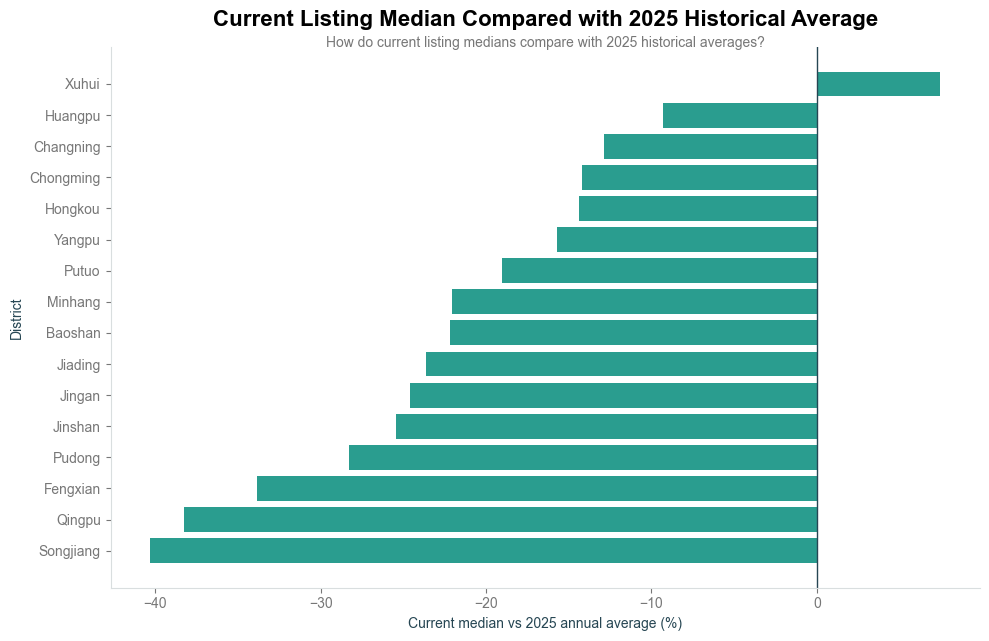

,district_std,buy_listings,median_buy_price_sqm,median_total_price,median_buy_area,avg_annual_price_per_sqm,current_vs_2025_pct
14,Xuhui,135,85738.0,7090000.0,88.16,79778.0,7.47
5,Huangpu,148,102145.0,11600000.0,113.68,112655.0,-9.33
1,Changning,118,65429.0,5230000.0,83.96,75119.0,-12.90
2,Chongming,149,15143.0,1250000.0,87.22,17646.0,-14.18
4,Hongkou,139,60896.0,4300000.0,75.05,71105.0,-14.36
15,Yangpu,135,57513.0,4950000.0,84.68,68251.0,-15.73
11,Putuo,116,52251.0,4725000.0,91.98,64542.0,-19.04
9,Minhang,115,45712.0,4290000.0,91.11,58634.0,-22.04
0,Baoshan,121,35379.0,2850000.0,81.27,45457.0,-22.17
6,Jiading,116,31966.5,2590000.0,86.69,41847.0,-23.61


In [21]:

hist_2025 = annual[annual["year"] == 2025][
    ["district_std", "avg_annual_price_per_sqm"]
]

current_gap = buy_summary.merge(hist_2025, on="district_std", how="left")
current_gap["current_vs_2025_pct"] = (
    current_gap["median_buy_price_sqm"]
    / current_gap["avg_annual_price_per_sqm"]
    - 1
) * 100

data = current_gap.sort_values("current_vs_2025_pct")

plt.figure(figsize=(10, 7))
plt.barh(data["district_std"], data["current_vs_2025_pct"])
plt.axvline(0, color=NAVY, linewidth=1)
plt.xlabel("Current median vs 2025 annual average (%)")
plt.ylabel("District")
set_chart_title(
    "Current Listing Median Compared with 2025 Historical Average",
    "How do current listing medians compare with 2025 historical averages?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(current_gap.sort_values("current_vs_2025_pct", ascending=False).round(2))



Only Xuhui’s current listing median is above its 2025 historical average, by about 7.5%. Most districts are below the historical value, with the largest gaps in Songjiang, Qingpu and Fengxian. This should not be read as a direct market-price decline because the chart compares a current listing median with an annual historical average calculated from a different dataset.


## 9. Property area versus total price

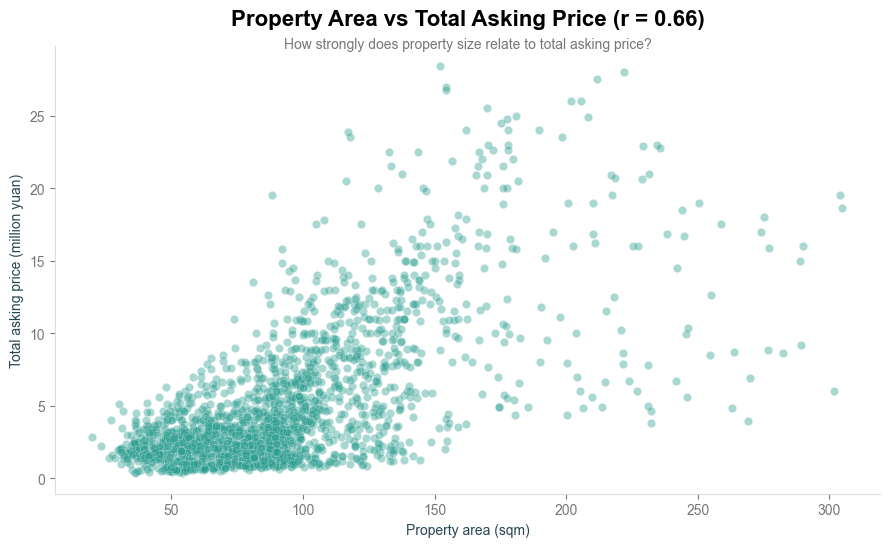

In [22]:

buy_scatter = buy[
    (buy["area_sqm"] <= buy["area_sqm"].quantile(0.99))
    & (buy["total_price_yuan"] <= buy["total_price_yuan"].quantile(0.99))
].copy()

correlation = buy_scatter[["area_sqm", "total_price_yuan"]].corr().iloc[0, 1]

plt.figure(figsize=(9, 6))
plt.scatter(
    buy_scatter["area_sqm"],
    buy_scatter["total_price_yuan"] / 1_000_000,
    alpha=0.4,
    color=TEAL,
    edgecolors="white",
    linewidths=0.3,
)
plt.xlabel("Property area (sqm)")
plt.ylabel("Total asking price (million yuan)")
set_chart_title(
    f"Property Area vs Total Asking Price (r = {correlation:.2f})",
    "How strongly does property size relate to total asking price?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


Property area and total asking price have a moderately strong positive relationship, with a correlation of 0.66. Larger homes generally cost more in total, but the wide vertical spread shows that properties of similar size can have very different prices. District, building quality and other characteristics therefore remain important.


## 10. Property age

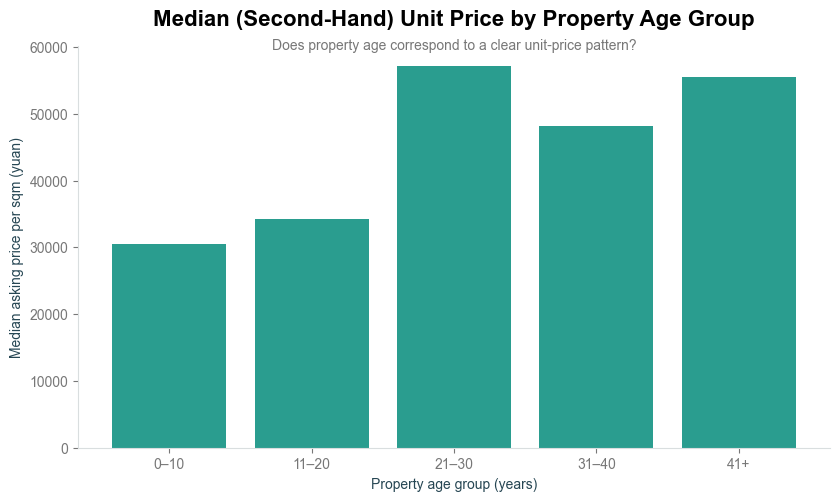

,age_group,listings,median_price_sqm,median_total_price
0,0–10,339,30560.0,2850000.0
1,11–20,676,34292.0,3300000.0
2,21–30,590,57215.5,5185000.0
3,31–40,336,48173.5,2390000.0
4,41+,90,55573.0,2410000.0


In [24]:

age_summary = (
    buy_age.groupby("age_group", observed=False)
    .agg(
        listings=("listing_url", "count"),
        median_price_sqm=("unit_price_yuan_sqm", "median"),
        median_total_price=("total_price_yuan", "median"),
    )
    .reset_index()
)

plt.figure(figsize=(8.5, 5.5))
plt.bar(age_summary["age_group"].astype(str), age_summary["median_price_sqm"])
plt.xlabel("Property age group (years)")
plt.ylabel("Median asking price per sqm (yuan)")
set_chart_title(
    "Median (Second-Hand) Unit Price by Property Age Group",
    "Does property age correspond to a clear unit-price pattern?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

age_summary



The relationship between property age and unit price is not linear. Homes aged 21–30 years have the highest median price in this grouping, while the newest properties have a lower median. This likely reflects location differences: many older homes are located in expensive central districts, so age should not be interpreted in isolation.


## 11. Decoration status

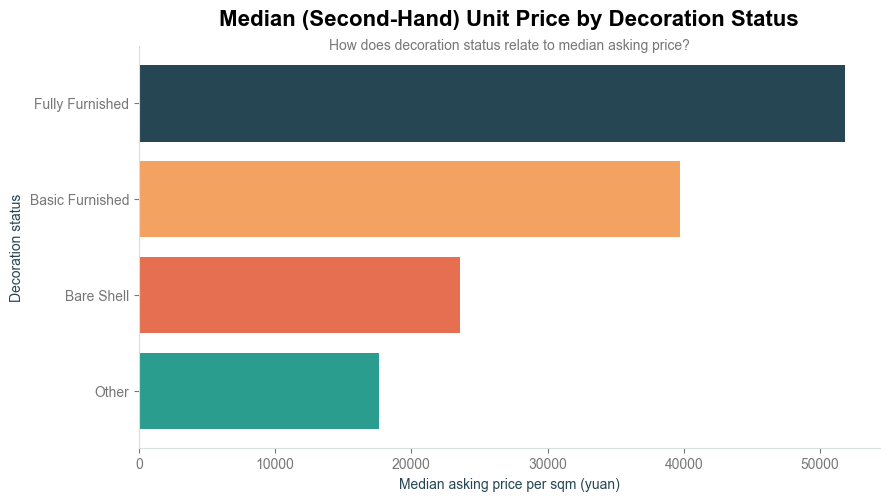

,decoration_en,listings,median_price_sqm,median_total_price,median_area
0,Bare Shell,166,23552.5,1900000.0,87.44
1,Basic Furnished,712,39677.0,2600000.0,76.29
2,Fully Furnished,1141,51796.0,4400000.0,90.62
3,Other,65,17626.0,1700000.0,89.62


In [26]:

decoration_summary = (
    buy.groupby("decoration_en")
    .agg(
        listings=("listing_url", "count"),
        median_price_sqm=("unit_price_yuan_sqm", "median"),
        median_total_price=("total_price_yuan", "median"),
        median_area=("area_sqm", "median"),
    )
    .reset_index()
)

data = decoration_summary.sort_values("median_price_sqm")

plt.figure(figsize=(9, 5.5))
plt.barh(
    data["decoration_en"],
    data["median_price_sqm"],
    color=palette_colors(len(data)),
)
plt.xlabel("Median asking price per sqm (yuan)")
plt.ylabel("Decoration status")
set_chart_title(
    "Median (Second-Hand) Unit Price by Decoration Status",
    "How does decoration status relate to median asking price?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

decoration_summary.round(2)



Fully furnished properties have the highest median unit price at 51,796 yuan per sqm, compared with 39,677 yuan for basic furnishing and 23,553 yuan for bare-shell units. Decoration status is clearly associated with price, although part of the difference may also reflect district, property quality and building type.


## 12. Floor level and building type

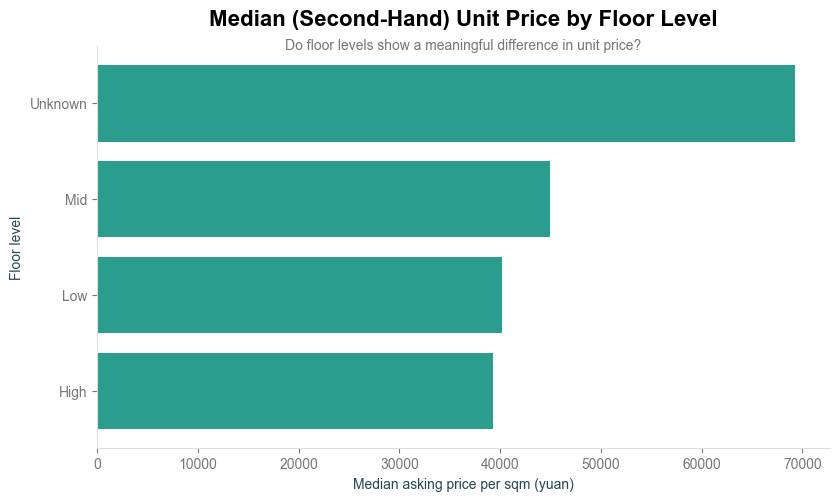

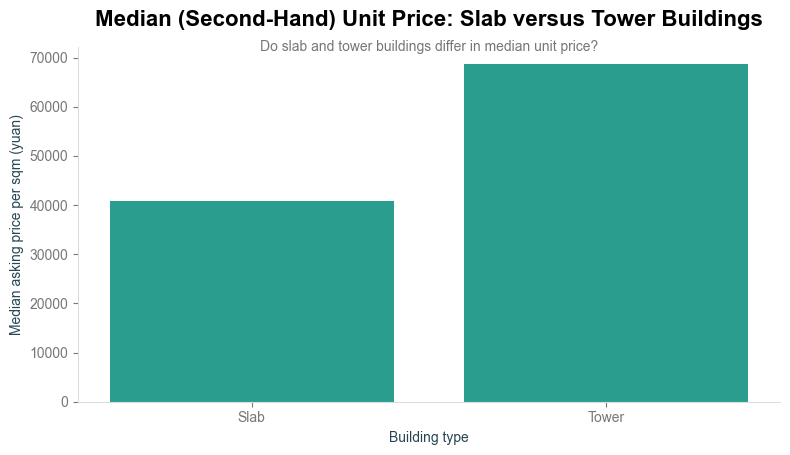

,floor_level_en,listings,median_price_sqm
0,High,698,39315.5
1,Low,537,40136.0
2,Mid,694,44936.0
3,Unknown,155,69267.0


,building_type_en,listings,median_price_sqm
0,Slab,1805,40912.0
1,Tower,162,68729.5


In [29]:

floor_summary = (
    buy.groupby("floor_level_en")
    .agg(
        listings=("listing_url", "count"),
        median_price_sqm=("unit_price_yuan_sqm", "median"),
    )
    .reset_index()
)

building_summary = (
    buy[buy["building_type_en"].isin(["Slab", "Tower"])]
    .groupby("building_type_en")
    .agg(
        listings=("listing_url", "count"),
        median_price_sqm=("unit_price_yuan_sqm", "median"),
    )
    .reset_index()
)

plt.figure(figsize=(8.5, 5.5))
plt.barh(
    floor_summary.sort_values("median_price_sqm")["floor_level_en"],
    floor_summary.sort_values("median_price_sqm")["median_price_sqm"],
)
plt.xlabel("Median asking price per sqm (yuan)")
plt.ylabel("Floor level")
set_chart_title(
    "Median (Second-Hand) Unit Price by Floor Level",
    "Do floor levels show a meaningful difference in unit price?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(building_summary["building_type_en"], building_summary["median_price_sqm"])
plt.xlabel("Building type")
plt.ylabel("Median asking price per sqm (yuan)")
set_chart_title(
    "Median (Second-Hand) Unit Price: Slab versus Tower Buildings",
    "Do slab and tower buildings differ in median unit price?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(floor_summary.round(2))
display(building_summary.round(2))


Mid-floor properties have the highest median among the known categories at 44,936 yuan per sqm, while low- and high-floor properties are close to 40,000 yuan. The “Unknown” category is much higher, but it should not be interpreted as a real floor-level effect because it represents missing information.

Tower buildings have a higher median unit price than slab buildings: about 68,730 versus 40,912 yuan per sqm. However, the tower sample is much smaller and may be concentrated in more expensive locations, so the chart shows association rather than a pure building-type premium.


## 13. Bedroom count and sale-variable correlations

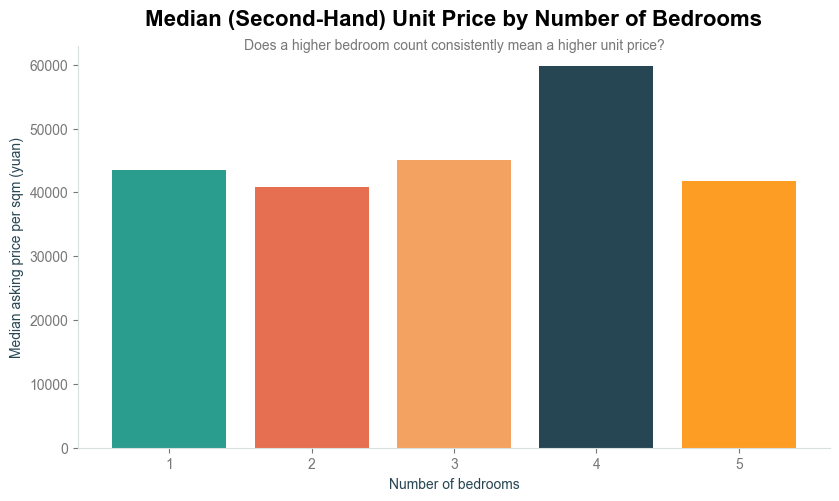

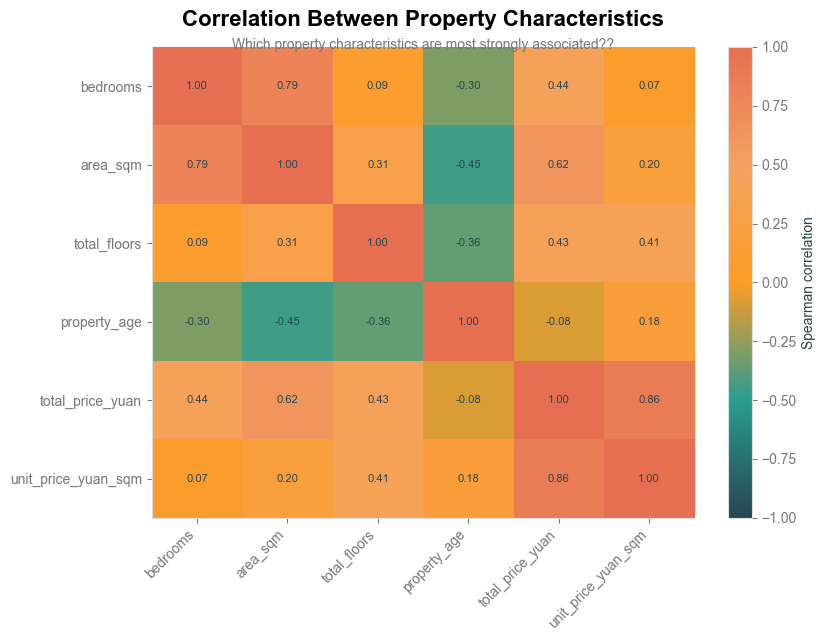

,bedrooms,listings,median_price_sqm,median_total_price,median_area
0,1.0,309,43533.0,1950000.0,47.83
1,2.0,983,40835.0,2850000.0,79.40
2,3.0,636,44997.0,4800000.0,113.60
3,4.0,121,59866.0,10300000.0,180.96
4,5.0,27,41738.0,13780000.0,276.61


,bedrooms,area_sqm,total_floors,property_age,total_price_yuan,unit_price_yuan_sqm
bedrooms,1.00,0.79,0.09,-0.30,0.44,0.07
area_sqm,0.79,1.00,0.31,-0.45,0.62,0.20
total_floors,0.09,0.31,1.00,-0.36,0.43,0.41
property_age,-0.30,-0.45,-0.36,1.00,-0.08,0.18
total_price_yuan,0.44,0.62,0.43,-0.08,1.00,0.86
unit_price_yuan_sqm,0.07,0.20,0.41,0.18,0.86,1.00


In [31]:

bedroom_summary = (
    buy[buy["bedrooms"].between(1, 5)]
    .groupby("bedrooms")
    .agg(
        listings=("listing_url", "count"),
        median_price_sqm=("unit_price_yuan_sqm", "median"),
        median_total_price=("total_price_yuan", "median"),
        median_area=("area_sqm", "median"),
    )
    .reset_index()
)

plt.figure(figsize=(8.5, 5.5))
plt.bar(
    bedroom_summary["bedrooms"].astype(int).astype(str),
    bedroom_summary["median_price_sqm"],
    color=palette_colors(len(bedroom_summary)),
)
plt.xlabel("Number of bedrooms")
plt.ylabel("Median asking price per sqm (yuan)")
set_chart_title(
    "Median (Second-Hand) Unit Price by Number of Bedrooms",
    "Does a higher bedroom count consistently mean a higher unit price?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

sale_numeric = buy[
    [
        "bedrooms",
        "area_sqm",
        "total_floors",
        "property_age",
        "total_price_yuan",
        "unit_price_yuan_sqm",
    ]
]

correlation_matrix = sale_numeric.corr(method="spearman")

plt.figure(figsize=(8.5, 7))
image = plt.imshow(
    correlation_matrix.to_numpy(),
    aspect="auto",
    cmap=PROJECT_CMAP,
    vmin=-1,
    vmax=1,
)
plt.colorbar(image, label="Spearman correlation")
plt.xticks(
    np.arange(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right",
)
plt.yticks(
    np.arange(len(correlation_matrix.index)),
    correlation_matrix.index,
)
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )
set_chart_title(
    "Correlation Between Property Characteristics",
    "Which property characteristics are most strongly associated??",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(bedroom_summary.round(2))
display(correlation_matrix.round(2))


Four-bedroom properties have the highest median unit price, but the pattern is not consistently upward across bedroom groups. Five-bedroom properties have a lower median and only 27 observations, so their result is less stable.

 Bedrooms are strongly related to area (0.79), and area is moderately related to total price (0.62). Bedroom count has only a weak relationship with unit price (0.07), suggesting that more rooms mainly increase the size and total cost rather than the price of each square metre.


## 14. Adjusted sale-price model

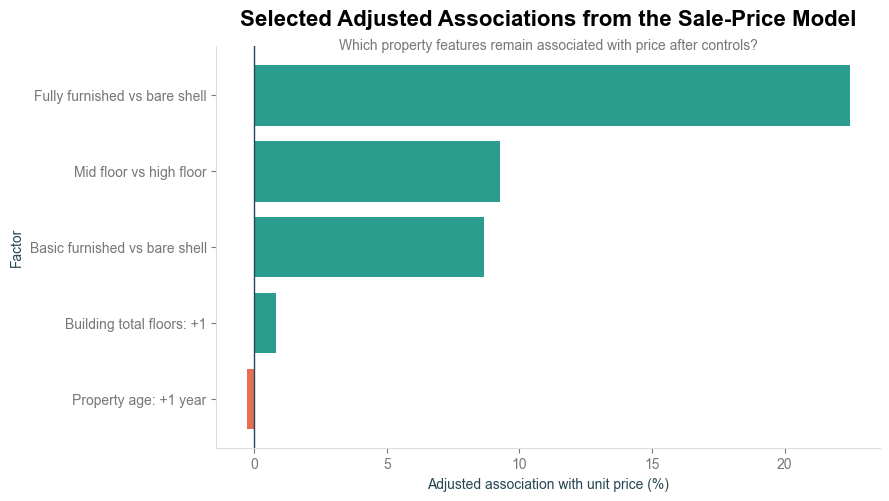

Model R-squared: 0.833


,factor,adjusted_effect_pct,p_value
0,Fully furnished vs bare shell,22.459,0.000
1,Basic furnished vs bare shell,8.663,0.003
2,Mid floor vs high floor,9.261,0.000
3,Property age: +1 year,-0.293,0.009
4,Building total floors: +1,0.817,0.000


In [32]:

reg_buy = buy[
    (buy["unit_price_yuan_sqm"] > 0)
    & (buy["area_sqm"] > 0)
    & buy["property_age"].notna()
    & (buy["property_age"] >= 0)
].copy()

reg_buy["log_price_sqm"] = np.log(reg_buy["unit_price_yuan_sqm"])
reg_buy["log_area"] = np.log(reg_buy["area_sqm"])
reg_buy["building_group"] = reg_buy["building_type_en"].where(
    reg_buy["building_type_en"].isin(["Slab", "Tower", "Unknown"]),
    "Other",
)

sale_model = smf.ols(
    '''
    log_price_sqm ~ log_area + bedrooms + property_age + total_floors
    + C(district_std) + C(decoration_en)
    + C(floor_level_en) + C(building_group)
    ''',
    data=reg_buy,
).fit(cov_type="HC3")

selected_terms = [
    ("Fully furnished vs bare shell", "C(decoration_en)[T.Fully Furnished]"),
    ("Basic furnished vs bare shell", "C(decoration_en)[T.Basic Furnished]"),
    ("Mid floor vs high floor", "C(floor_level_en)[T.Mid]"),
    ("Property age: +1 year", "property_age"),
    ("Building total floors: +1", "total_floors"),
]

results = []

for label, term in selected_terms:
    if term in sale_model.params:
        results.append({
            "factor": label,
            "adjusted_effect_pct": (np.exp(sale_model.params[term]) - 1) * 100,
            "p_value": sale_model.pvalues[term],
        })

adjusted_sale = pd.DataFrame(results)

plt.figure(figsize=(9, 5.5))
data = adjusted_sale.sort_values("adjusted_effect_pct")
plt.barh(
    data["factor"],
    data["adjusted_effect_pct"],
    color=[CORAL if value < 0 else TEAL for value in data["adjusted_effect_pct"]],
)
plt.axvline(0, color=NAVY, linewidth=1)
plt.xlabel("Adjusted association with unit price (%)")
plt.ylabel("Factor")
set_chart_title(
    "Selected Adjusted Associations from the Sale-Price Model",
    "Which property features remain associated with price after controls?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print("Model R-squared:", round(sale_model.rsquared, 3))
display(adjusted_sale.round(3))


After district, area and other property characteristics are controlled, fully furnished units are associated with a 22.5% higher unit price than bare-shell units. Basic furnishing and mid-floor location also remain positively associated with price, while each additional year of property age is linked to a small decrease. The model explains about 83.3% of the variation, but the coefficients should still be interpreted as associations rather than causal effects.


## 15. Monthly rent and rent per sqm by district

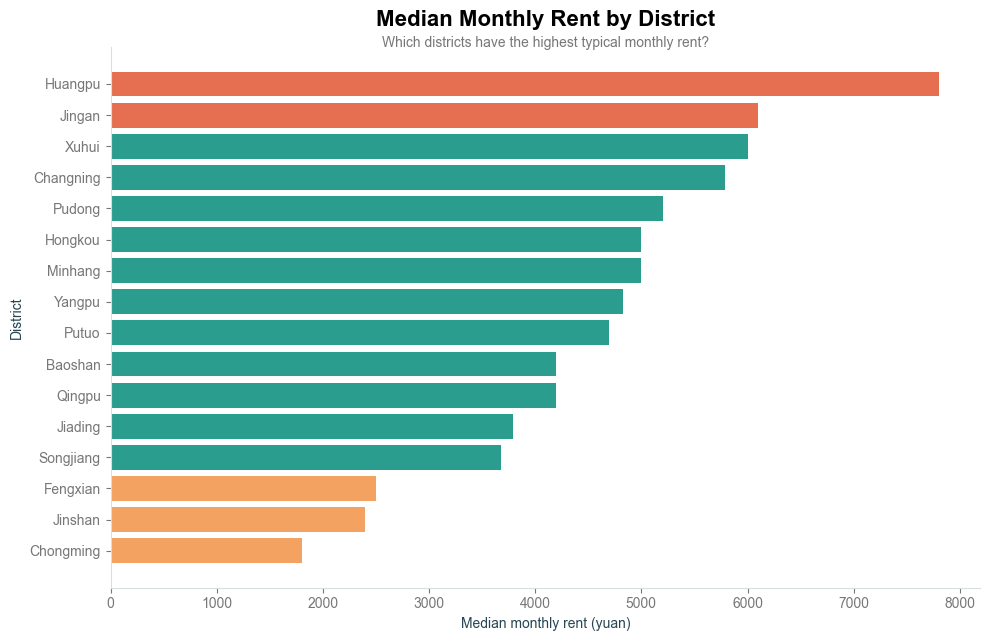

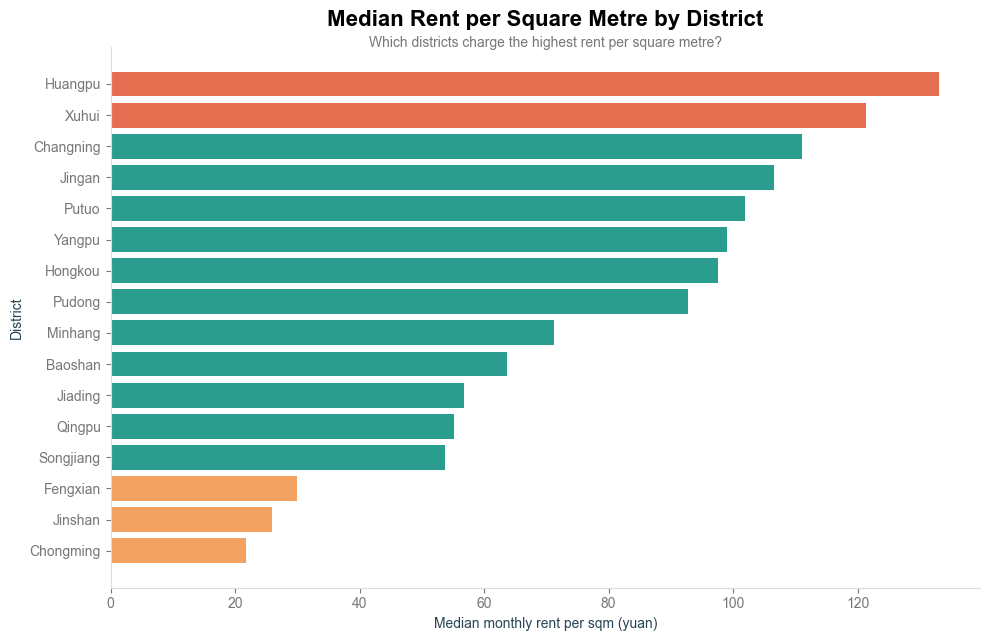

In [33]:

data = market.sort_values("median_monthly_rent")

plt.figure(figsize=(10, 7))
plt.barh(data["district_std"], data["median_monthly_rent"], color=ranked_colors(len(data)))
plt.xlabel("Median monthly rent (yuan)")
plt.ylabel("District")
set_chart_title(
    "Median Monthly Rent by District",
    "Which districts have the highest typical monthly rent?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

data = market.sort_values("median_rent_sqm")

plt.figure(figsize=(10, 7))
plt.barh(data["district_std"], data["median_rent_sqm"], color=ranked_colors(len(data)))
plt.xlabel("Median monthly rent per sqm (yuan)")
plt.ylabel("District")
set_chart_title(
    "Median Rent per Square Metre by District",
    "Which districts charge the highest rent per square metre?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


 Huangpu has the highest median monthly rent at 7,800 yuan, followed by Jingan and Xuhui. Chongming has the lowest median at 1,800 yuan. Monthly totals are influenced by both location and the typical size of rental properties.

 The ranking remains strongly centralised after property size is taken into account. Huangpu records 133 yuan per sqm, compared with 21.8 yuan in Chongming. Rent per sqm is therefore a better measure for comparing the location premium across districts.


## 16. Layout and rental area

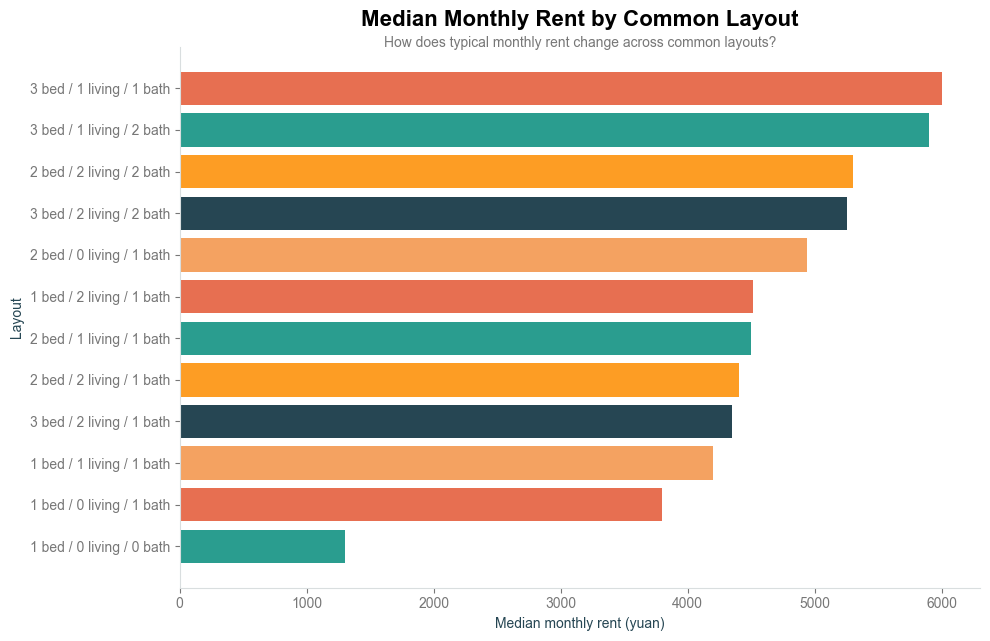

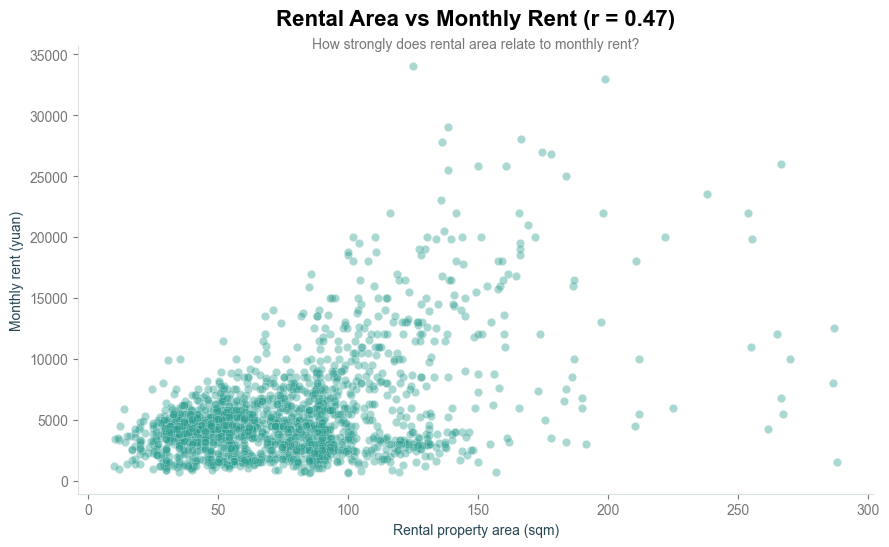

,layout_en,listings,median_monthly_rent,median_rent_sqm,median_area
0,1 bed / 0 living / 0 bath,21,1300.0,36.70,34.94
1,1 bed / 0 living / 1 bath,116,3800.0,126.65,30.47
2,1 bed / 1 living / 1 bath,461,4200.0,98.80,42.46
18,3 bed / 2 living / 1 bath,96,4350.0,46.20,94.35
10,2 bed / 2 living / 1 bath,239,4400.0,52.60,88.90
8,2 bed / 1 living / 1 bath,419,4500.0,69.40,67.00
4,1 bed / 2 living / 1 bath,24,4515.0,70.00,62.90
6,2 bed / 0 living / 1 bath,26,4941.5,99.90,49.50
19,3 bed / 2 living / 2 bath,197,5250.0,48.00,127.51
11,2 bed / 2 living / 2 bath,45,5300.0,66.40,106.05


In [34]:

layout_summary = (
    rent_valid.groupby("layout_en")
    .agg(
        listings=("listing_url", "count"),
        median_monthly_rent=("monthly_rent_yuan", "median"),
        median_rent_sqm=("rent_per_sqm", "median"),
        median_area=("area_sqm", "median"),
    )
    .reset_index()
)

layout_summary = layout_summary[
    layout_summary["listings"] >= 20
].sort_values("median_monthly_rent")

plt.figure(figsize=(10, 7))
plt.barh(
    layout_summary["layout_en"],
    layout_summary["median_monthly_rent"],
    color=palette_colors(len(layout_summary)),
)
plt.xlabel("Median monthly rent (yuan)")
plt.ylabel("Layout")
set_chart_title(
    "Median Monthly Rent by Common Layout",
    "How does typical monthly rent change across common layouts?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

rent_scatter = rent_valid[
    (rent_valid["area_sqm"] <= rent_valid["area_sqm"].quantile(0.99))
    & (rent_valid["monthly_rent_yuan"] <= rent_valid["monthly_rent_yuan"].quantile(0.99))
].copy()

rent_area_corr = rent_scatter[["area_sqm", "monthly_rent_yuan"]].corr().iloc[0, 1]

plt.figure(figsize=(9, 6))
plt.scatter(
    rent_scatter["area_sqm"],
    rent_scatter["monthly_rent_yuan"],
    alpha=0.4,
    color=TEAL,
    edgecolors="white",
    linewidths=0.3,
)
plt.xlabel("Rental property area (sqm)")
plt.ylabel("Monthly rent (yuan)")
set_chart_title(
    f"Rental Area vs Monthly Rent (r = {rent_area_corr:.2f})",
    "How strongly does rental area relate to monthly rent?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(layout_summary.round(2))


 Larger layouts generally require higher monthly rent, but the ranking is not perfectly ordered. Some compact one-bedroom units have high rent per sqm, while several larger layouts have moderate total rents, indicating that location and property condition also matter.

 Rental area and monthly rent have a correlation of about 0.47. Size matters, but the substantial spread around the trend shows that it explains only part of the difference in monthly rent.


## 17. Metro proximity

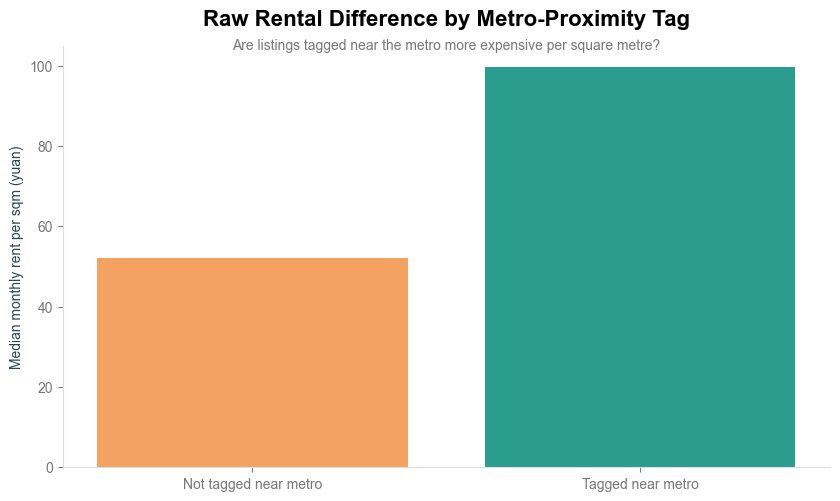

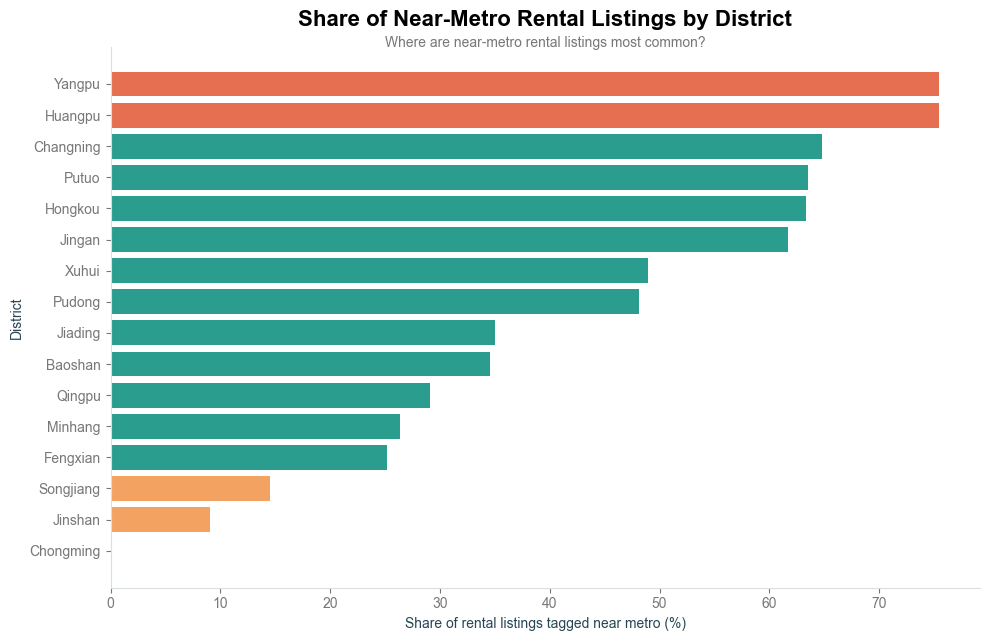

,near_metro,listings,median_rent_sqm,median_monthly_rent,median_area,group
0,False,1085,52.0,3800.0,81.85,Not tagged near metro
1,True,765,99.8,5000.0,56.63,Tagged near metro


In [35]:

metro_overall = (
    rent_valid.groupby("near_metro")
    .agg(
        listings=("listing_url", "count"),
        median_rent_sqm=("rent_per_sqm", "median"),
        median_monthly_rent=("monthly_rent_yuan", "median"),
        median_area=("area_sqm", "median"),
    )
    .reset_index()
)

metro_overall["group"] = metro_overall["near_metro"].map(
    {False: "Not tagged near metro", True: "Tagged near metro"}
)

plt.figure(figsize=(8.5, 5.5))
plt.bar(
    metro_overall["group"],
    metro_overall["median_rent_sqm"],
    color=[ORANGE, TEAL],
)
plt.ylabel("Median monthly rent per sqm (yuan)")
plt.xlabel("")
set_chart_title(
    "Raw Rental Difference by Metro-Proximity Tag",
    "Are listings tagged near the metro more expensive per square metre?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

metro_share = (
    rent_valid.groupby("district_std")["near_metro"]
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(10, 7))
plt.barh(metro_share.index, metro_share.values, color=ranked_colors(len(metro_share)))
plt.xlabel("Share of rental listings tagged near metro (%)")
plt.ylabel("District")
set_chart_title(
    "Share of Near-Metro Rental Listings by District",
    "Where are near-metro rental listings most common?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(metro_overall.round(2))


 Listings tagged as near a metro station have a median rent of 99.8 yuan per sqm, compared with 52.0 yuan for other listings. Near-metro units are also smaller on average, so the higher unit rent is not explained by larger property size.

 Near-metro listings are most common in Huangpu and Yangpu, where they account for about 75% of the rental sample. They are rare in Jinshan and absent in Chongming. This uneven geographic distribution explains part of the large raw rent difference.


## 18. Within-district and adjusted metro effects

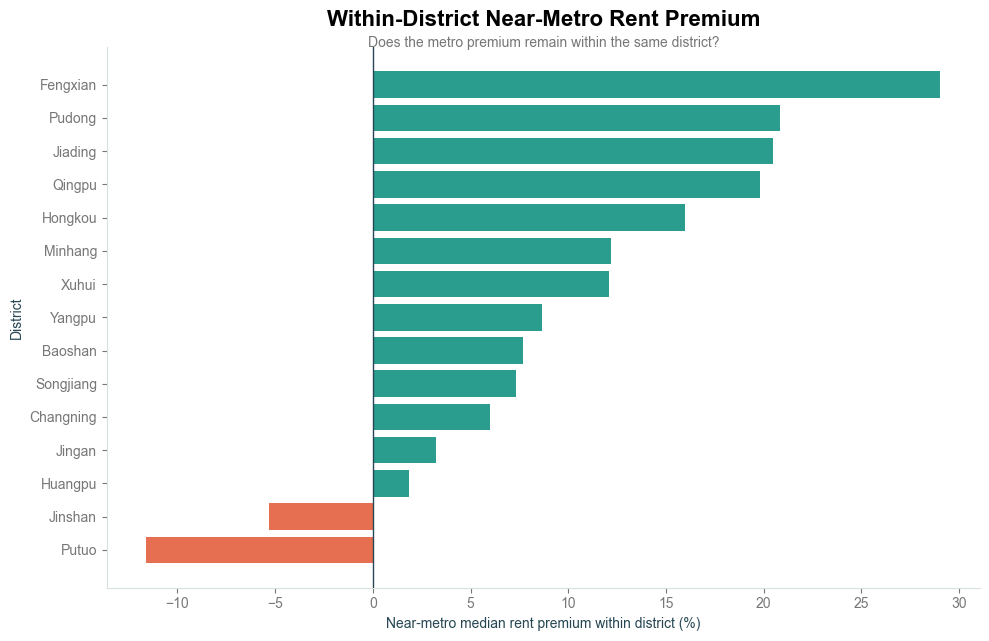

Adjusted near-metro association: 6.97 %
p-value: 0.0002369422933065407
Model R-squared: 0.757


In [36]:

metro_district = (
    rent_valid.groupby(["district_std", "near_metro"])
    .agg(
        listings=("listing_url", "count"),
        median_rent_sqm=("rent_per_sqm", "median"),
    )
    .reset_index()
)

metro_n = metro_district.pivot(
    index="district_std",
    columns="near_metro",
    values="listings",
)

metro_r = metro_district.pivot(
    index="district_std",
    columns="near_metro",
    values="median_rent_sqm",
)

valid_districts = metro_n[
    (metro_n[False] >= 10)
    & (metro_n[True] >= 10)
].index

within_premium = (
    (
        metro_r.loc[valid_districts, True]
        / metro_r.loc[valid_districts, False]
        - 1
    )
    * 100
).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(
    within_premium.index,
    within_premium.values,
    color=[CORAL if value < 0 else TEAL for value in within_premium.values],
)
plt.axvline(0, color=NAVY, linewidth=1)
plt.xlabel("Near-metro median rent premium within district (%)")
plt.ylabel("District")
set_chart_title(
    "Within-District Near-Metro Rent Premium",
    "Does the metro premium remain within the same district?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

reg_rent = rent_valid[
    (rent_valid["rent_per_sqm"] > 0)
    & (rent_valid["area_sqm"] > 0)
    & rent_valid["bedrooms"].notna()
].copy()

reg_rent["log_rent_sqm"] = np.log(reg_rent["rent_per_sqm"])
reg_rent["log_area"] = np.log(reg_rent["area_sqm"])

rent_model = smf.ols(
    '''
    log_rent_sqm ~ log_area + bedrooms + near_metro
    + C(district_std)
    ''',
    data=reg_rent,
).fit(cov_type="HC3")

adjusted_metro = (
    np.exp(rent_model.params["near_metro[T.True]"]) - 1
) * 100

print("Adjusted near-metro association:", round(adjusted_metro, 2), "%")
print("p-value:", rent_model.pvalues["near_metro[T.True]"])
print("Model R-squared:", round(rent_model.rsquared, 3))




Within most districts, near-metro listings still have higher median rent per sqm, although the size of the premium varies. Fengxian, Pudong and Jiading show some of the largest positive differences, while Putuo and Jinshan show negative values. After district, area and bedrooms are controlled, the estimated near-metro association falls to about 7.0% but remains statistically significant.


## 19. Price-to-rent and investor positioning

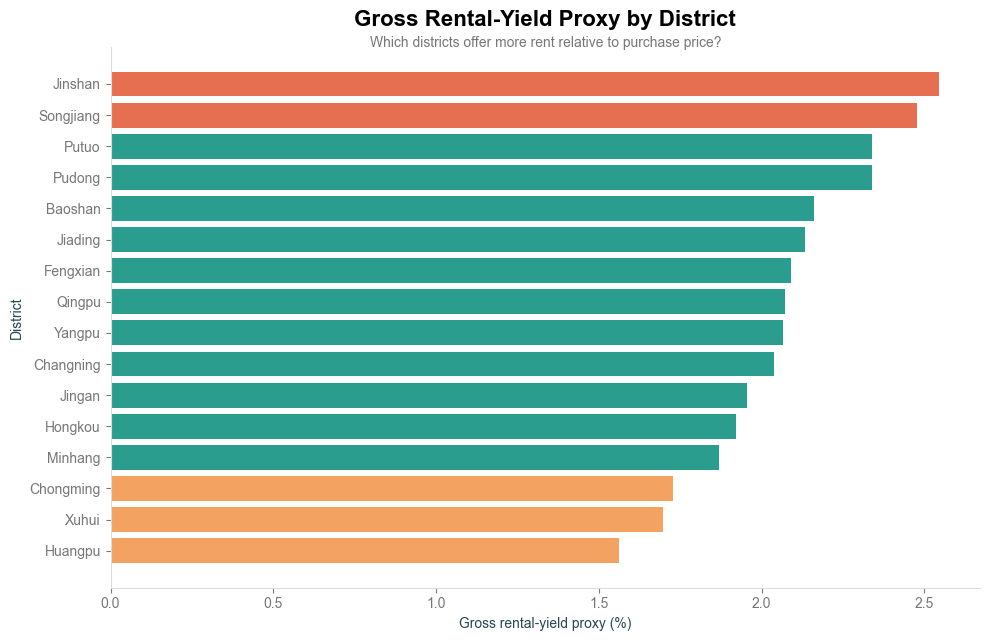

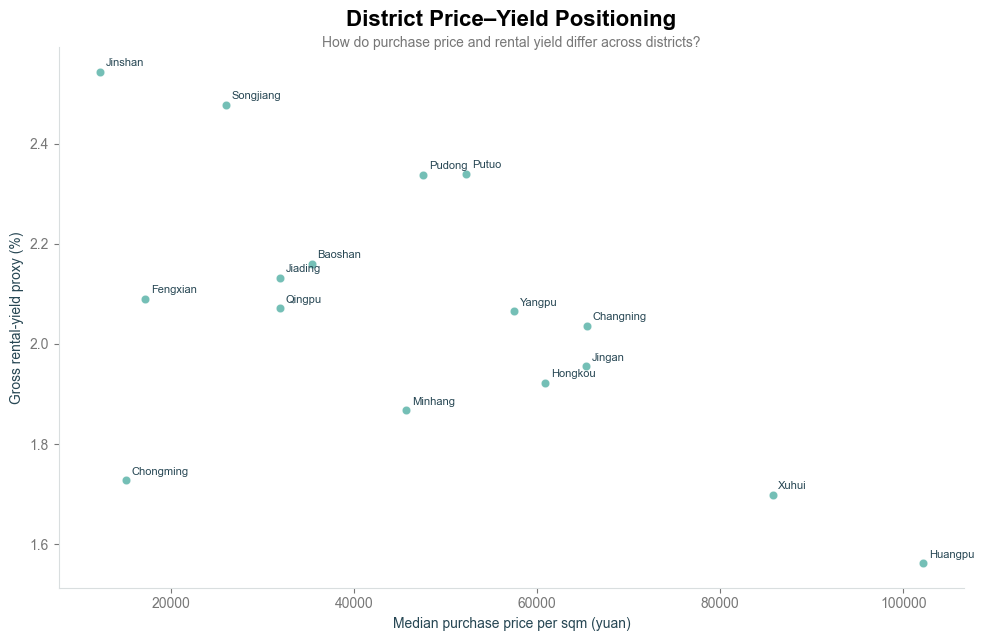

,district_std,gross_rental_yield_pct,price_to_rent_years,median_buy_price_sqm
8,Jinshan,2.54,39.31,12265.0
13,Songjiang,2.48,40.36,26009.0
11,Putuo,2.34,42.73,52251.0
10,Pudong,2.34,42.77,47582.0
0,Baoshan,2.16,46.28,35379.0
6,Jiading,2.13,46.90,31966.5
3,Fengxian,2.09,47.85,17227.0
12,Qingpu,2.07,48.28,31921.0
15,Yangpu,2.07,48.41,57513.0
1,Changning,2.04,49.10,65429.0


In [37]:

data = market.sort_values("gross_rental_yield_pct")

plt.figure(figsize=(10, 7))
plt.barh(data["district_std"], data["gross_rental_yield_pct"], color=ranked_colors(len(data)))
plt.xlabel("Gross rental-yield proxy (%)")
plt.ylabel("District")
set_chart_title(
    "Gross Rental-Yield Proxy by District",
    "Which districts offer more rent relative to purchase price?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

plt.figure(figsize=(10, 7))
plt.scatter(
    market["median_buy_price_sqm"],
    market["gross_rental_yield_pct"],
    color=TEAL,
    alpha=0.65,
    edgecolors="white",
    linewidths=0.3,
)
for _, row in market.iterrows():
    plt.annotate(
        row["district_std"],
        (
            row["median_buy_price_sqm"],
            row["gross_rental_yield_pct"],
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )
plt.xlabel("Median purchase price per sqm (yuan)")
plt.ylabel("Gross rental-yield proxy (%)")
set_chart_title(
    "District Price–Yield Positioning",
    "How do purchase price and rental yield differ across districts?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(
    market.sort_values("gross_rental_yield_pct", ascending=False)[
        [
            "district_std",
            "gross_rental_yield_pct",
            "price_to_rent_years",
            "median_buy_price_sqm",
        ]
    ].round(2)
)


 Jinshan and Songjiang have the highest values at approximately 2.54% and 2.48%, while Huangpu and Xuhui have the lowest at 1.56% and 1.70%. **Lower-priced districts therefore generate more rent relative to their purchase price.**

 The scatter plot shows a general negative relationship between purchase price and rental yield. Central districts appear more suitable for buyers focused on location or long-term capital value, whereas some outer districts offer stronger current rental income relative to price. The measure is gross and excludes expenses and vacancy.


## 20. Historical heatmap and selected district trends

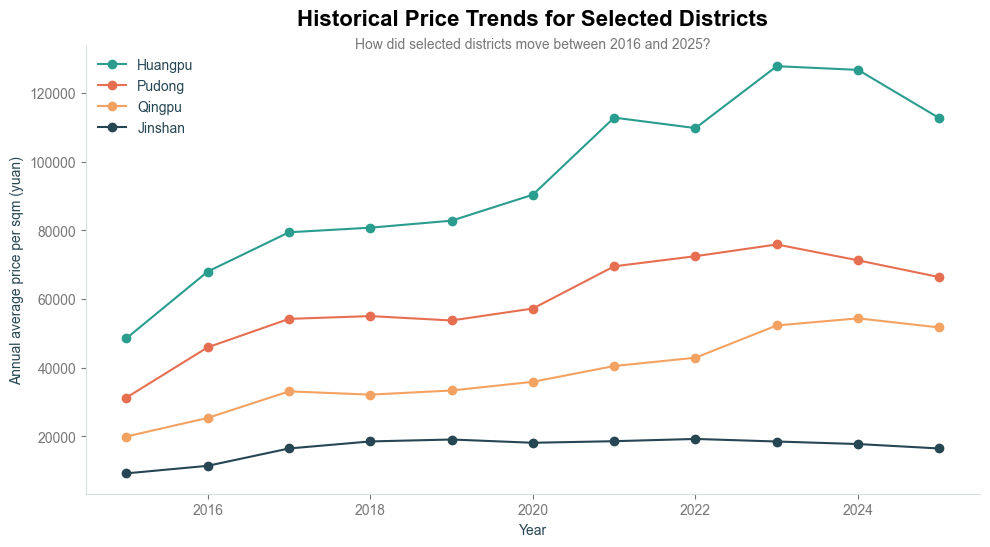

In [39]:
selected_districts = ["Huangpu", "Pudong", "Qingpu", "Jinshan"]

plt.figure(figsize=(10, 6))
for district in selected_districts:
    data = annual[annual["district_std"] == district].sort_values("year")
    plt.plot(
        data["year"],
        data["avg_annual_price_per_sqm"],
        marker="o",
        label=district,
    )
plt.xlabel("Year")
plt.ylabel("Annual average price per sqm (yuan)")
set_chart_title(
    "Historical Price Trends for Selected Districts",
    "How did selected districts move between 2016 and 2025?",
)
plt.legend()
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


All four selected districts are more expensive in 2025 than at the beginning of the period, but their paths differ. Huangpu remains by far the most expensive, while Qingpu shows especially strong long-term growth from a lower starting point. Most series reached a local peak between 2022 and 2024 and then declined by 2025, indicating a broad recent correction.


## 21. Volatility

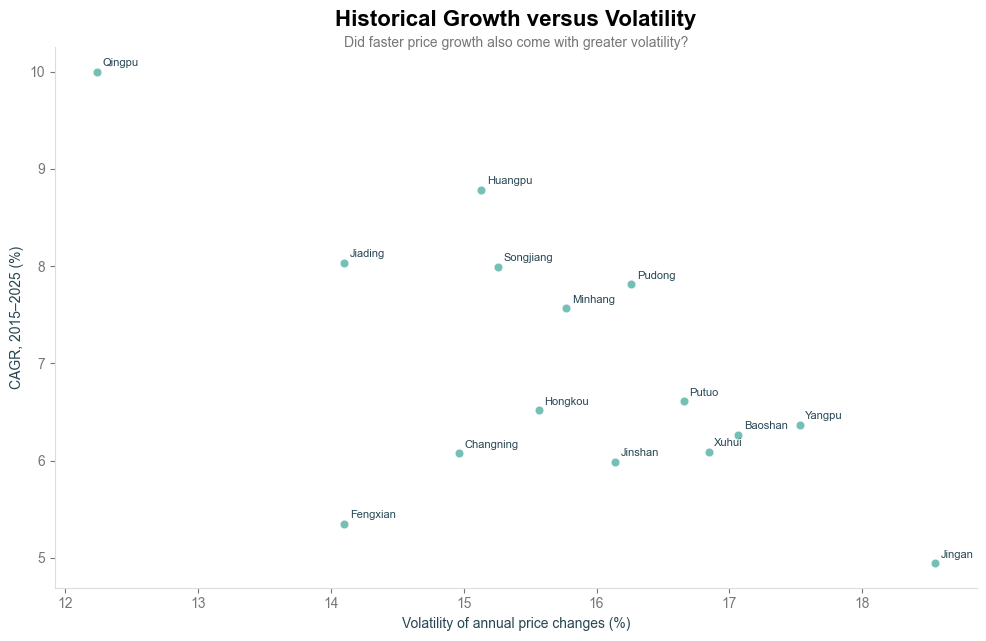

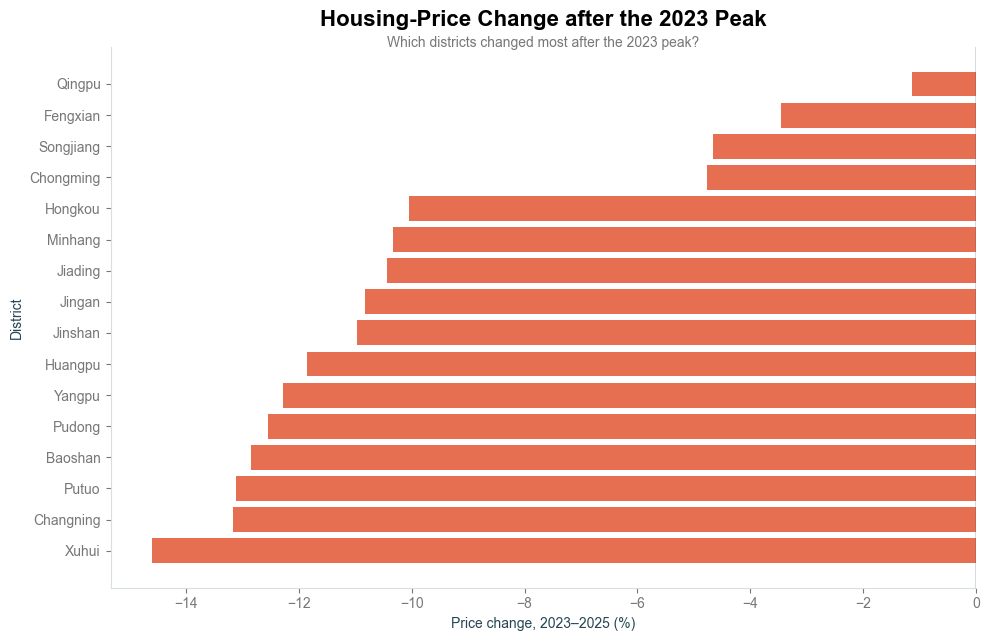

,district_std,growth_2015_2025_pct,cagr_2015_2025_pct,annual_change_volatility_pct,change_2023_2025_pct
12,Qingpu,159.38,10.00,12.24,-1.13
5,Huangpu,132.09,8.78,15.13,-11.85
6,Jiading,116.57,8.03,14.10,-10.43
13,Songjiang,115.76,7.99,15.26,-4.66
10,Pudong,112.22,7.81,16.26,-12.54
9,Minhang,107.41,7.57,15.77,-10.33
11,Putuo,89.67,6.61,16.66,-13.12
4,Hongkou,88.03,6.52,15.57,-10.06
15,Yangpu,85.43,6.37,17.53,-12.29
0,Baoshan,83.63,6.27,17.07,-12.84


In [41]:

annual_pivot = annual.pivot(
    index="district_std",
    columns="year",
    values="avg_annual_price_per_sqm",
)

growth = pd.DataFrame(index=annual_pivot.index)

growth["growth_2015_2025_pct"] = (
    annual_pivot[2025] / annual_pivot[2015] - 1
) * 100

growth["cagr_2015_2025_pct"] = (
    (annual_pivot[2025] / annual_pivot[2015]) ** (1 / 10) - 1
) * 100

annual_returns = annual_pivot.pct_change(axis=1, fill_method=None) * 100

growth["annual_change_volatility_pct"] = annual_returns.std(
    axis=1,
    skipna=True,
)

growth["change_2023_2025_pct"] = (
    annual_pivot[2025] / annual_pivot[2023] - 1
) * 100

growth = growth.reset_index()

data = growth.dropna(subset=["cagr_2015_2025_pct"]).sort_values("cagr_2015_2025_pct")


plt.figure(figsize=(10, 7))
plt.scatter(
    data["annual_change_volatility_pct"],
    data["cagr_2015_2025_pct"],
    color=TEAL,
    alpha=0.65,
    edgecolors="white",
    linewidths=0.3,
)
for _, row in data.iterrows():
    plt.annotate(
        row["district_std"],
        (
            row["annual_change_volatility_pct"],
            row["cagr_2015_2025_pct"],
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )
plt.xlabel("Volatility of annual price changes (%)")
plt.ylabel("CAGR, 2015–2025 (%)")
set_chart_title(
    "Historical Growth versus Volatility",
    "Did faster price growth also come with greater volatility?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

data = growth.sort_values("change_2023_2025_pct")

plt.figure(figsize=(10, 7))
plt.barh(
    data["district_std"],
    data["change_2023_2025_pct"],
    color=[CORAL if value < 0 else TEAL for value in data["change_2023_2025_pct"]],
)
plt.axvline(0, color=NAVY, linewidth=1)
plt.xlabel("Price change, 2023–2025 (%)")
plt.ylabel("District")
set_chart_title(
    "Housing-Price Change after the 2023 Peak",
    "Which districts changed most after the 2023 peak?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(growth.sort_values("cagr_2015_2025_pct", ascending=False).round(2))


 Qingpu combines the highest CAGR with the lowest historical volatility in this comparison. Jingan shows the opposite pattern, with the lowest CAGR and the highest volatility, indicating a less favourable historical risk–growth balance.

 Every district with available data declined between 2023 and 2025. Xuhui experienced the largest decrease at about 14.6%, while Qingpu was the most stable with a decline of only 1.1%.


## Chloropeth - Median (Second-Hand) Unit Price per sqm by District

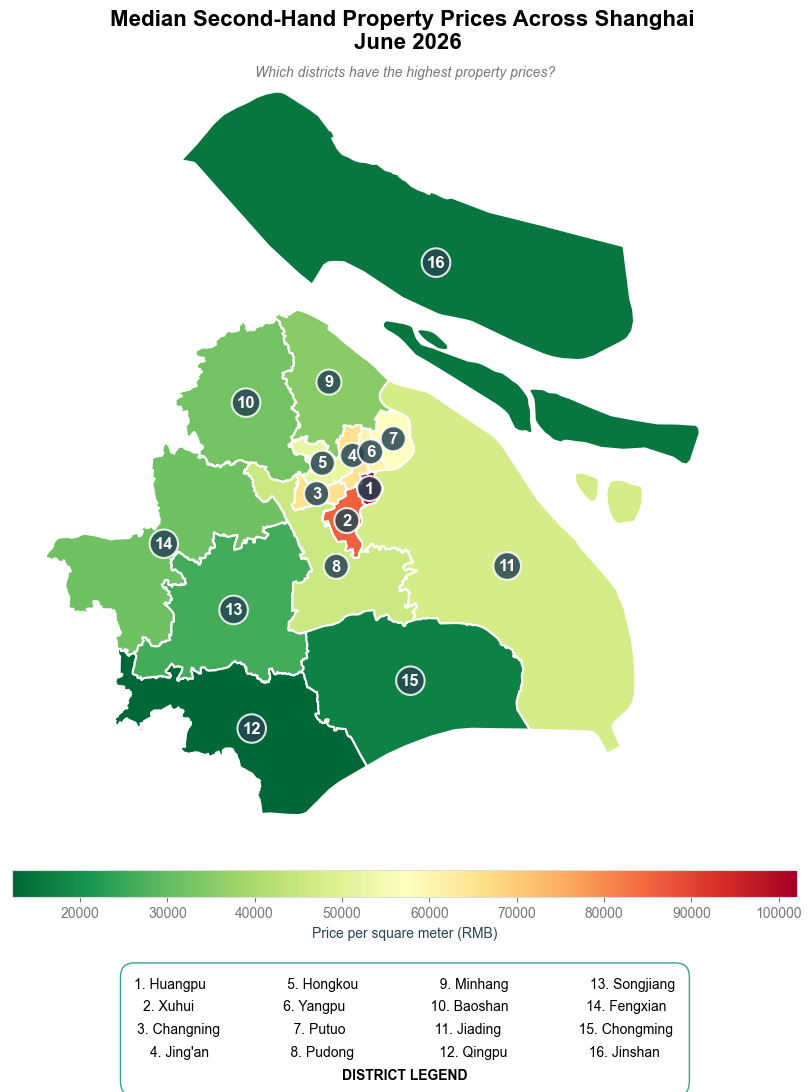

In [7]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from pathlib import Path
project_root = Path.cwd().parent
data_dir = project_root / "data"
df = pd.read_csv(data_dir / "lianjia_buy_clean_20260606.csv")

buy_dist = df.groupby('district').agg({
    'unit_price_yuan_sqm': 'median'
}).reset_index()

district_en_map = {
    'huangpu': 'Huangpu',
    'jingan': "Jing'an",
    'xuhui': 'Xuhui',
    'changning': 'Changning',
    'putuo': 'Putuo',
    'hongkou': 'Hongkou',
    'yangpu': 'Yangpu',
    'pudong': 'Pudong',
    'minhang': 'Minhang',
    'baoshan': 'Baoshan',
    'jiading': 'Jiading',
    'songjiang': 'Songjiang',
    'qingpu': 'Qingpu',
    'fengxian': 'Fengxian',
    'jinshan': 'Jinshan',
    'chongming': 'Chongming'
}

buy_dist['district_en'] = buy_dist['district'].str.lower().map(district_en_map)

gdf = gpd.read_file(data_dir / "shanghai_districts.geojson")

geojson_map = {
    "黄浦区": "Huangpu",
    "静安区": "Jing'an",
    "徐汇区": "Xuhui",
    "长宁区": "Changning",
    "普陀区": "Putuo",
    "虹口区": "Hongkou",
    "杨浦区": "Yangpu",
    "浦东新区": "Pudong",
    "闵行区": "Minhang",
    "宝山区": "Baoshan",
    "嘉定区": "Jiading",
    "松江区": "Songjiang",
    "青浦区": "Qingpu",
    "奉贤区": "Fengxian",
    "金山区": "Jinshan",
    "崇明区": "Chongming"
}

gdf['district_en'] = gdf['name'].map(geojson_map)
gdf = gdf.merge(buy_dist[['district_en', 'unit_price_yuan_sqm']], 
                on='district_en', how='left')


fig, ax = plt.subplots(figsize=(16, 12), facecolor='white')
ax.set_facecolor('white')
ax.set_axis_off()

gdf.plot(
    column='unit_price_yuan_sqm',
    cmap='RdYlGn_r',
    edgecolor='white',
    linewidth=1.5,
    legend=True,
    legend_kwds={
        'label': 'Price per square meter (RMB)',
        'orientation': 'horizontal',
        'shrink': 0.5,
        'pad': 0.02,
        'aspect': 30
    },
    ax=ax
)

districts_with_data = gdf[gdf['unit_price_yuan_sqm'].notna()].copy()
districts_with_data = districts_with_data.sort_values('unit_price_yuan_sqm', ascending=False)
district_to_num = {row['district_en']: idx + 1 for idx, row in districts_with_data.iterrows()}

for _, row in gdf.iterrows():
    if pd.notna(row['unit_price_yuan_sqm']):
        centroid = row.geometry.centroid
        num = district_to_num[row['district_en']]
        ax.annotate(
            str(num),
            xy=(centroid.x, centroid.y),
            fontsize=12,
            ha='center',
            va='center',
            fontweight='bold',
            color='white',
            bbox=dict(
                boxstyle='circle,pad=0.3', 
                facecolor=NAVY, 
                alpha=0.85,
                edgecolor='white',
                linewidth=1.5
            )
        )

ax.set_title(
    'Median Second-Hand Property Prices Across Shanghai \n June 2026',
    fontsize=16, 
    fontweight='bold', 
    fontname='Arial', 
    color='black',
    pad=5
)

ax.text(
    0.5, 0.97,
    'Which districts have the highest property prices?',
    fontsize=10,
    fontname='Arial', 
    color=GREY,
    ha='center', 
    va='bottom', 
    transform=ax.transAxes, fontstyle='italic',
)


sorted_districts = buy_dist.sort_values('unit_price_yuan_sqm', ascending=False)
sorted_districts['num'] = range(1, len(sorted_districts) + 1)

col1 = sorted_districts.iloc[0:4]
col2 = sorted_districts.iloc[4:8]
col3 = sorted_districts.iloc[8:12]
col4 = sorted_districts.iloc[12:16]

legend_text = ""
for i in range(4):
    row1 = f"{col1.iloc[i]['num']}. {col1.iloc[i]['district_en']}" if i < len(col1) else ""
    row2 = f"{col2.iloc[i]['num']}. {col2.iloc[i]['district_en']}" if i < len(col2) else ""
    row3 = f"{col3.iloc[i]['num']}. {col3.iloc[i]['district_en']}" if i < len(col3) else ""
    row4 = f"{col4.iloc[i]['num']}. {col4.iloc[i]['district_en']}" if i < len(col4) else ""
    
    legend_text += f"{row1:<30} {row2:<30} {row3:<30} {row4}\n"

ax.text(
    0.5, -0.29,
    legend_text,
    fontsize=10,
    fontname='Arial',
    color='black',
    ha='center',
    va='bottom',
    transform=ax.transAxes,
    linespacing=1.8,
    bbox=dict(
        boxstyle='round,pad=1.0',
        facecolor='white',
        edgecolor=TEAL,
        alpha=0.95,
        linewidth=1
    )
)

ax.text(
    0.5, -0.29,
    'DISTRICT LEGEND',
    fontsize=10,
    fontname='Arial',
    color='black',
    weight='bold',
    ha='center',
    va='bottom',
    transform=ax.transAxes
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig(data_dir / 'shanghai_prices_map.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Additional Distribution Analysis

In [47]:

def boxplot_summary(data, group_col, value_col):
    result = (
        data.groupby(group_col)[value_col]
        .agg(
            count="count",
            q1=lambda x: x.quantile(0.25),
            median="median",
            q3=lambda x: x.quantile(0.75),
            minimum="min",
            maximum="max",
        )
        .reset_index()
    )
    result["iqr"] = result["q3"] - result["q1"]

    outlier_counts = []

    for _, row in result.iterrows():
        values = data.loc[
            data[group_col] == row[group_col],
            value_col,
        ].dropna()

        lower = row["q1"] - 1.5 * row["iqr"]
        upper = row["q3"] + 1.5 * row["iqr"]

        outlier_counts.append(
            ((values < lower) | (values > upper)).sum()
        )

    result["boxplot_outliers"] = outlier_counts
    result["outlier_share_pct"] = (
        result["boxplot_outliers"] / result["count"] * 100
    )

    return result



## Boxplot 1: Purchase price per sqm by district


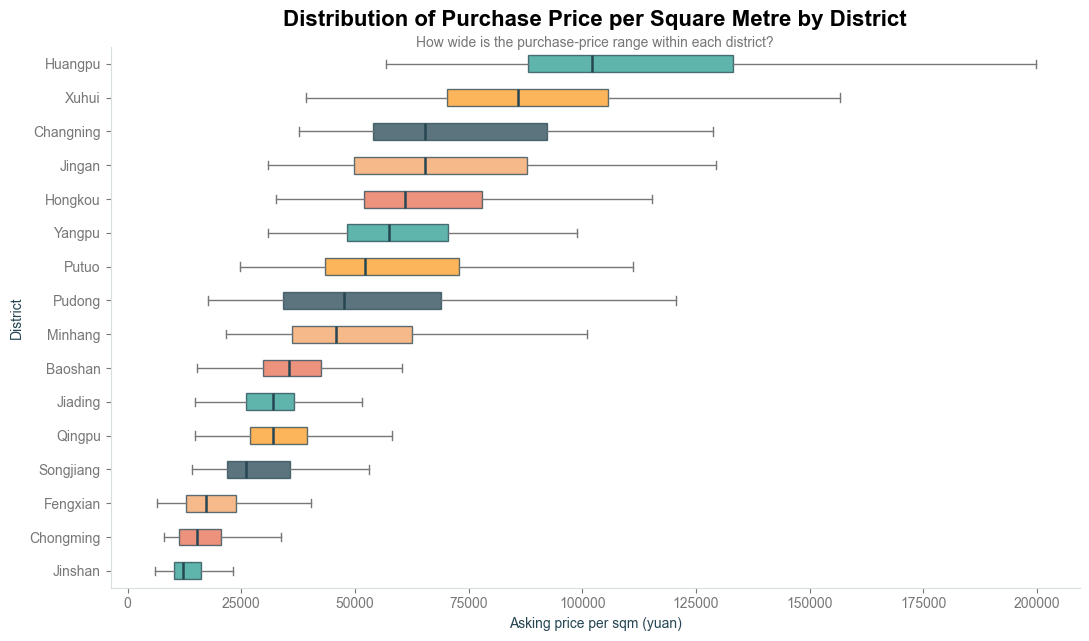

,district_std,count,q1,median,q3,minimum,maximum,iqr,boxplot_outliers,outlier_share_pct
5,Huangpu,148,87984.00,102145.0,133210.50,56719.0,256497.0,45226.50,6,4.05
14,Xuhui,135,70230.00,85738.0,105635.00,39172.0,171154.0,35405.00,3,2.22
1,Changning,118,54038.25,65429.0,92142.00,37778.0,128752.0,38103.75,0,0.00
7,Jingan,121,49878.00,65353.0,87841.00,30947.0,145346.0,37963.00,1,0.83
4,Hongkou,139,51982.00,60896.0,77945.00,32545.0,135594.0,25963.00,7,5.04
15,Yangpu,135,48173.50,57513.0,70375.00,30972.0,134971.0,22201.50,7,5.19
11,Putuo,116,43313.75,52251.0,72964.25,24723.0,138122.0,29650.50,1,0.86
10,Pudong,126,34183.50,47582.0,68962.25,17597.0,209171.0,34778.75,8,6.35
9,Minhang,115,36191.00,45712.0,62549.00,21648.0,111682.0,26358.00,1,0.87
0,Baoshan,121,29811.00,35379.0,42572.00,15218.0,69512.0,12761.00,1,0.83


In [48]:

sale_box_summary = boxplot_summary(
    buy,
    "district_std",
    "unit_price_yuan_sqm",
).sort_values("median")

order = sale_box_summary["district_std"].tolist()

plt.figure(figsize=(11, 7))
styled_boxplot(
    [
        buy.loc[
            buy["district_std"] == district,
            "unit_price_yuan_sqm",
        ].dropna()
        for district in order
    ],
    labels=order,
    vert=False,
    showfliers=False,
)
plt.xlabel("Asking price per sqm (yuan)")
plt.ylabel("District")
set_chart_title(
    "Distribution of Purchase Price per Square Metre by District",
    "How wide is the purchase-price range within each district?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(
    sale_box_summary.sort_values("median", ascending=False).round(2)
)



Central districts have both higher medians and wider price ranges. Huangpu has a median of 102,145 yuan per sqm and an interquartile range of about 45,227 yuan, while Pudong also shows substantial internal variation. This confirms that one district can contain several different housing segments and that the median alone does not describe the full market.



## Boxplot 2: Rent per sqm by district


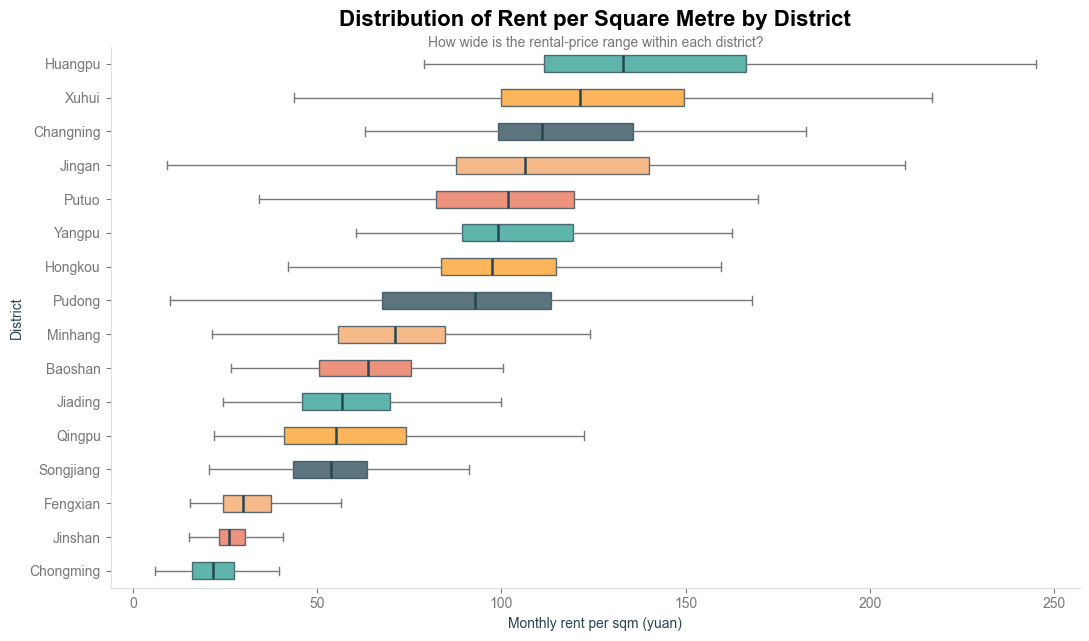

,district_std,count,q1,median,q3,minimum,maximum,iqr,boxplot_outliers,outlier_share_pct
5,Huangpu,122,111.60,133.00,166.38,5.2,447.8,54.77,5,4.10
14,Xuhui,98,99.85,121.35,149.65,43.7,433.8,49.80,6,6.12
1,Changning,108,99.00,111.05,135.62,29.6,281.7,36.62,4,3.70
7,Jingan,115,87.65,106.50,139.95,9.3,330.1,52.30,4,3.48
11,Putuo,115,82.15,101.90,119.70,4.5,186.9,37.55,3,2.61
15,Yangpu,122,89.28,99.00,119.32,60.6,233.3,30.05,5,4.10
4,Hongkou,120,83.68,97.55,114.92,42.2,307.4,31.25,6,5.00
10,Pudong,108,67.55,92.70,113.52,10.0,167.9,45.98,0,0.00
9,Minhang,110,55.62,71.15,84.75,21.4,141.6,29.12,5,4.55
0,Baoshan,113,50.60,63.70,75.50,26.7,149.2,24.90,3,2.65


In [49]:

rent_box_summary = boxplot_summary(
    rent_valid,
    "district_std",
    "rent_per_sqm",
).sort_values("median")

order = rent_box_summary["district_std"].tolist()

plt.figure(figsize=(11, 7))
styled_boxplot(
    [
        rent_valid.loc[
            rent_valid["district_std"] == district,
            "rent_per_sqm",
        ].dropna()
        for district in order
    ],
    labels=order,
    vert=False,
    showfliers=False,
)
plt.xlabel("Monthly rent per sqm (yuan)")
plt.ylabel("District")
set_chart_title(
    "Distribution of Rent per Square Metre by District",
    "How wide is the rental-price range within each district?",
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

display(
    rent_box_summary.sort_values("median", ascending=False).round(2)
)




The rental boxplots show the same central–outer divide as the median chart. Huangpu, Xuhui and Jingan have high medians and broad interquartile ranges, while Jinshan and Chongming have much lower and tighter distributions. Central rental markets are therefore not only more expensive but also more diverse.
